### Project Backlog
P1 Project Setup
* Choose the dataset

* Define research questions

* Create GitHub repository

* Assign responsibilities


P2 Data Cleaning
* Load dataset

* Check missing values

* Remove duplicates

* Convert data types

* Export cleaned dataset

P3 Univariate EDA
* Summary statistics

* Histograms

* Boxplots

* Bar charts

* Conclusions

P4 Bivariate EDA
* GroupBy

* Crosstab

* Scatterplots

* Correlation

* Conclusions

P5 SQL
* Import dataset

* Create table

* Write queries

* Save queries

P6 Documentation
* README

* Notebook comments

* Conclusions

P7 Presentation
* Slides

* Assign speakers

* Practice

P8 Final Review
* Merge branches

* Final checks

* Submit

### Questions - Targets

Q1 How accurately do Expected Goals (xG) predict the final match result?
Why? Expected Goals (xG) is one of the most important metrics in modern football
analytics.
Main Variables: Home xG, Away xG, Home Goals, Away Goals, League, Season.
Possible Analysis: Correlation between xG and goals, comparison across leagues and
seasons

Q2 Does recent team performance influence match outcomes?
Why? The dataset contains extensive information about recent team performance.
Main Variables: Previous Points, Previous Goals Scored, Previous Goals Conceded,
Previous xG, Match Result, League.
Possible Analysis: Team form, winning probability and performance trends

Q3 Do teams with more current points consistently achieve better match results?
Why? Evaluate whether the number of points accumulated before a match predicts
future performance.
Main Variables: Current Points, Goals, xG, Match Result, League, Season.
Possible Analysis: Current points vs wins, goals and Expected Goals

Q4 How do team player ratings and team formations influence match performance?
Why? Uses team-level player ratings together with tactical formations.
Main Variables: Team Player Ratings (Defense, Midfield, Attack), Formation, Goals, xG.
Possible Analysis: Ratings vs goals, ratings vs xG, best formations and league
comparisons

Q5 Which league has the highest average Expected Goals (xG) per match?

Q6 Which league produces the highest average number of goals per match?

Q7 Is there a relationship between Expected Goals (xG) and actual goals scored?

Q8 Which league is the most competitive based on goal difference and match results?

Q9 Does home advantage vary across Europe's Top Five Leagues?

Q10 How does team form affect Expected Goals (xG) in future matches?

Q11 Which formations are associated with the highest attacking performance?

Q12 Do teams with higher player ratings consistently outperform lower-rated teams?

### Individual Notebook Structure
S1 Introduction Briefly explain the dataset and the assigned research question

S2 Import Libraries pandas, numpy, matplotlib, seaborn if allowed, sqlite3 if needed

S3 SLoad Dataset Read the CSV and confirm the file loads correctly

S4 ISnitial Exploration head(), shape, info(), columns, dtypes, describe()

S5 Data Quality Checks Missing values, duplicates, invalid values, categorical values

S6 CleSaning Decisions Keep/drop columns, fix types, handle missing values, document choices

S7 Feature Engineering 

* Step 6 Create xg_difference
* Step 7 Create points_difference


S8 EDA PSractice Univariate and bivariate analysis related to the assigned question

S9 InsighSts Write 3-5 clear observations from the analysis

S10 Final SNotes What worked, what should be included in the final team notebook

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

### S5 Data Quality Checks

In [2]:
df = pd.read_csv(r"dataset/football_matches_dataset.csv")

In [3]:
df.shape

(16332, 55)

In [4]:
df.head()

,Unnamed: 0,home_team,away_team,date,league,season,home_score,away_score,home_xg,away_xg,...,home_defense_rating_last_2_home_matches,away_defense_rating_last_2_away_matches,home_midfield_rating_last_4_matches,away_midfield_rating_last_4_matches,home_midfield_rating_last_2_home_matches,away_midfield_rating_last_2_away_matches,home_attack_rating_last_4_matches,away_attack_rating_last_4_matches,home_attack_rating_last_2_home_matches,away_attack_rating_last_2_away_matches
0,0,Reims,Paris Saint Germain,August 08 2014,Ligue 1,2014/2015,2,2,1.37,2.66,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Evian Thonon Gaillard,Caen,August 09 2014,Ligue 1,2014/2015,0,3,0.81,1.24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Guingamp,Saint-Etienne,August 09 2014,Ligue 1,2014/2015,0,2,0.63,1.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Lille,Metz,August 09 2014,Ligue 1,2014/2015,0,0,1.54,0.06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Montpellier,Bordeaux,August 09 2014,Ligue 1,2014/2015,0,1,1.02,0.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16332 entries, 0 to 16331
Data columns (total 55 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Unnamed: 0                                16332 non-null  int64  
 1   home_team                                 16332 non-null  str    
 2   away_team                                 16332 non-null  str    
 3   date                                      16332 non-null  str    
 4   league                                    16332 non-null  str    
 5   season                                    16332 non-null  str    
 6   home_score                                16332 non-null  int64  
 7   away_score                                16332 non-null  int64  
 8   home_xg                                   16332 non-null  float64
 9   away_xg                                   16332 non-null  float64
 10  datetime                                  163

<span style="color:red"> Missing around 300 !!

<span style="color:red"> and "date" and "datetime" are strings, we shoukd tranform it to datetime

In [6]:
round(df.describe().T, 2)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,16332.0,8165.50,4714.79,0.00,4082.75,8165.50,12248.25,16331.00
home_score,16332.0,1.54,1.31,0.00,1.00,1.00,2.00,10.00
away_score,16332.0,1.21,1.17,0.00,0.00,1.00,2.00,9.00
home_xg,16332.0,1.52,0.90,0.00,0.85,1.36,2.03,6.88
away_xg,16332.0,1.20,0.79,0.00,0.60,1.05,1.62,6.50
home_standings,16332.0,10.78,5.59,1.00,6.00,11.00,16.00,20.00
away_standings,16332.0,10.65,5.57,1.00,6.00,11.00,15.00,20.00
home_points,16332.0,24.71,17.92,0.00,10.00,22.00,36.00,94.00
away_points,16332.0,24.90,17.90,0.00,11.00,22.00,36.00,97.00
home_points_last_4_matches,16020.0,5.44,2.94,0.00,3.00,5.00,7.00,12.00


In [7]:
df.nunique()

Unnamed: 0                                  16332
home_team                                     157
away_team                                     157
date                                         1655
league                                          5
season                                          9
home_score                                     11
away_score                                     10
home_xg                                       519
away_xg                                       454
datetime                                     1655
home_standings                                 20
away_standings                                 20
home_points                                    94
away_points                                    97
home_points_last_4_matches                     12
away_points_last_4_matches                     12
home_points_last_2_home_matches                 6
away_points_last_2_away_matches                 6
home_goals_last_4_matches                      22


In [8]:
df.dtypes

Unnamed: 0                                    int64
home_team                                       str
away_team                                       str
date                                            str
league                                          str
season                                          str
home_score                                    int64
away_score                                    int64
home_xg                                     float64
away_xg                                     float64
datetime                                        str
home_standings                                int64
away_standings                                int64
home_points                                   int64
away_points                                   int64
home_points_last_4_matches                  float64
away_points_last_4_matches                  float64
home_points_last_2_home_matches             float64
away_points_last_2_away_matches             float64
home_goals_l

In [9]:
df.isna().sum()

Unnamed: 0                                    0
home_team                                     0
away_team                                     0
date                                          0
league                                        0
season                                        0
home_score                                    0
away_score                                    0
home_xg                                       0
away_xg                                       0
datetime                                      0
home_standings                                0
away_standings                                0
home_points                                   0
away_points                                   0
home_points_last_4_matches                  312
away_points_last_4_matches                  316
home_points_last_2_home_matches             314
away_points_last_2_away_matches             314
home_goals_last_4_matches                   312
away_goals_last_4_matches               

In [10]:
missing = df.isna().sum()
missing = missing[missing > 0]
missing

home_points_last_4_matches                  312
away_points_last_4_matches                  316
home_points_last_2_home_matches             314
away_points_last_2_away_matches             314
home_goals_last_4_matches                   312
away_goals_last_4_matches                   316
home_goals_last_2_home_matches              314
away_goals_last_2_away_matches              314
home_goals_against_last_4_matches           312
away_goals_against_last_4_matches           316
home_goals_against_last_2_home_matches      314
away_goals_against_last_2_away_matches      314
home_mean_xg_last_4_matches                 312
away_mean_xg_last_4_matches                 316
home_mean_xg_last_2_home_matches            314
away_mean_xg_last_2_away_matches            314
home_mean_xg_against_last_4_matches         312
away_mean_xg_against_last_4_matches         316
home_mean_xg_against_last_2_home_matches    314
away_mean_xg_against_last_2_away_matches    314
home_defense_rating_last_4_matches      

yes

In [11]:
df.duplicated().sum()

np.int64(0)

<span style="color:lightgreen">  No dupicates !!

In [12]:
df.eq(' ').sum()

Unnamed: 0                                  0
home_team                                   0
away_team                                   0
date                                        0
league                                      0
season                                      0
home_score                                  0
away_score                                  0
home_xg                                     0
away_xg                                     0
datetime                                    0
home_standings                              0
away_standings                              0
home_points                                 0
away_points                                 0
home_points_last_4_matches                  0
away_points_last_4_matches                  0
home_points_last_2_home_matches             0
away_points_last_2_away_matches             0
home_goals_last_4_matches                   0
away_goals_last_4_matches                   0
home_goals_last_2_home_matches    

<span style="color:lightgreen">  Clean data !!

In [13]:
df['date'] = pd.to_datetime(df['date'], format='%B\n%d\n%Y')
df['datetime'] = pd.to_datetime(df['datetime'], format='%Y-%m-%d')
df

,Unnamed: 0,home_team,away_team,date,league,season,home_score,away_score,home_xg,away_xg,...,home_defense_rating_last_2_home_matches,away_defense_rating_last_2_away_matches,home_midfield_rating_last_4_matches,away_midfield_rating_last_4_matches,home_midfield_rating_last_2_home_matches,away_midfield_rating_last_2_away_matches,home_attack_rating_last_4_matches,away_attack_rating_last_4_matches,home_attack_rating_last_2_home_matches,away_attack_rating_last_2_away_matches
0,0,Reims,Paris Saint Germain,2014-08-08,Ligue 1,2014/2015,2,2,1.37,2.66,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Evian Thonon Gaillard,Caen,2014-08-09,Ligue 1,2014/2015,0,3,0.81,1.24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Guingamp,Saint-Etienne,2014-08-09,Ligue 1,2014/2015,0,2,0.63,1.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Lille,Metz,2014-08-09,Ligue 1,2014/2015,0,0,1.54,0.06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Montpellier,Bordeaux,2014-08-09,Ligue 1,2014/2015,0,1,1.02,0.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16327,16327,Real Sociedad,Sevilla,2023-06-04,La liga,2022/2023,2,1,2.35,0.46,...,6.823000,7.251000,6.894917,6.580000,6.963500,6.475000,6.868750,6.993333,6.572500,7.430000
16328,16328,Real Valladolid,Getafe,2023-06-04,La liga,2022/2023,0,0,0.69,0.28,...,6.379000,6.749000,6.475000,6.718125,6.503333,6.639167,6.565833,6.632500,6.913333,6.095000
16329,16329,Roma,Spezia,2023-06-04,Serie A,2022/2023,2,1,2.28,1.11,...,6.389167,6.616000,6.573208,6.521667,6.493750,6.450000,6.518750,6.217083,6.445000,6.186667
16330,16330,Udinese,Juventus,2023-06-04,Serie A,2022/2023,0,1,0.96,1.47,...,6.938333,6.699167,6.595208,6.913500,6.815417,6.780000,6.521250,6.256250,6.447500,6.397500


In [14]:
negative_goals = df[(df['home_score'] < 0) | (df['away_score'] < 0)]
negative_xg = df[(df['home_xg'] < 0) | (df['away_xg'] < 0)]
# invalid_rating = df[(df['rating'] < 0) | (df['rating'] > 10)]
valid_leagues = ['Ligue 1']
unexpected_leagues = df[~df['league'].isin(valid_leagues)]

print("negative_goals:", negative_goals.shape[0])
print("negative_xg:", negative_xg.shape[0])
print("unexpected_leagues:", unexpected_leagues.shape[0])


negative_goals: 0
negative_xg: 0
unexpected_leagues: 13014


### Handle missing values
We identified ~300 missing values across columns.

Since this is a small fraction of 16,332 rows (less than 2%), we drop those rows to keep the dataset clean and complete

In [15]:
print(f"Rows before dropping NA {df.shape[0]}")
df_clean = df.dropna().copy()
print(f"Rows after dropping NA {df_clean.shape[0]}")
print(f"Dropped {df.shape[0] - df_clean.shape[0]} rows")

df_clean = df_clean.drop(columns=['Unnamed: 0'])
print(f"\nFinal columns {df_clean.shape[1]}")
print(f"Final shape {df_clean.shape}")

Rows before dropping NA 16332
Rows after dropping NA 15889
Dropped 443 rows

Final columns 54
Final shape (15889, 54)


In [16]:
df_clean.to_csv(r"dataset/football_matches_cleaned.csv", index=False)
print("Cleaned dataset exported ...")

Cleaned dataset exported ...


In [17]:
print("- Data Cleaning Summary -")
print(f"Shape: {df_clean.shape}")
print(f"Missing values remaining: {df_clean.isna().sum().sum()}")
print(f"Duplicates: {df_clean.duplicated().sum()}")
print(f"\nLeagues: {df_clean['league'].unique()}")
print(f"Seasons: {sorted(df_clean['season'].unique())}")
print(f"Date range: {df_clean['datetime'].min()} to {df_clean['datetime'].max()}")
df_clean.info()

- Data Cleaning Summary -
Shape: (15889, 54)
Missing values remaining: 0
Duplicates: 0

Leagues: <StringArray>
['Ligue 1', 'EPL', 'La liga', 'Bundesliga', 'Serie A']
Length: 5, dtype: str
Seasons: ['2014/2015', '2015/2016', '2016/2017', '2017/2018', '2018/2019', '2019/2020', '2020/2021', '2021/2022', '2022/2023']
Date range: 2014-09-12 00:00:00 to 2023-06-04 00:00:00
<class 'pandas.DataFrame'>
Index: 15889 entries, 120 to 16331
Data columns (total 54 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   home_team                                 15889 non-null  str           
 1   away_team                                 15889 non-null  str           
 2   date                                      15889 non-null  datetime64[us]
 3   league                                    15889 non-null  str           
 4   season                                    15889 non-null  str 

### S6 Cleaning decisions

Now we review the cleaned dataset and make additional column-level decisions:

* Drop redundant columns: If two columns contain identical information, keep only one
* Drop constant columns: If a column contains only a single value (e.g., all zeros), it provides no variance and should be removed
* Document all choices so the team can follow the logic

In [18]:
print("- Cleaning Decision 1: Identical Columns -")
# 'date' and 'datetime' contain the same information (different formats)
print(f"Columns before dropping 'date': {df_clean.shape[1]}")
if 'date' in df_clean.columns:
    df_clean = df_clean.drop(columns=['date'])
    print("Dropped 'date' column (identical to 'datetime')")
else:
    print("'date' column already dropped.")
print(f"Columns after: {df_clean.shape[1]}")

print("\n- Cleaning Decision 2: Zero-only / Constant Columns -")

constant_cols = [col for col in df_clean.columns if df_clean[col].nunique() <= 1]
print(f"Constant columns (no variance): {constant_cols if constant_cols else 'None found — all columns have variance!'}")

zero_cols = [col for col in df_clean.select_dtypes(include='number').columns if (df_clean[col] == 0).all()]
print(f"Zero-only columns: {zero_cols if zero_cols else 'None found!'}")

print(f"\nFinal shape after cleaning decisions: {df_clean.shape}")
print(f"Final columns ({df_clean.shape[1]}):")
print(list(df_clean.columns))

- Cleaning Decision 1: Identical Columns -
Columns before dropping 'date': 54
Dropped 'date' column (identical to 'datetime')
Columns after: 53

- Cleaning Decision 2: Zero-only / Constant Columns -
Constant columns (no variance): None found — all columns have variance!
Zero-only columns: None found!

Final shape after cleaning decisions: (15889, 53)
Final columns (53):
['home_team', 'away_team', 'league', 'season', 'home_score', 'away_score', 'home_xg', 'away_xg', 'datetime', 'home_standings', 'away_standings', 'home_points', 'away_points', 'home_points_last_4_matches', 'away_points_last_4_matches', 'home_points_last_2_home_matches', 'away_points_last_2_away_matches', 'home_goals_last_4_matches', 'away_goals_last_4_matches', 'home_goals_last_2_home_matches', 'away_goals_last_2_away_matches', 'home_goals_against_last_4_matches', 'away_goals_against_last_4_matches', 'home_goals_against_last_2_home_matches', 'away_goals_against_last_2_away_matches', 'home_mean_xg_last_4_matches', 'away_m

### S7 Feature Engineering

We create new features to support our analysis:

| Step | Feature | Formula | Description |
|------|---------|---------|-------------|
| **Step 6** | `xg_difference` | `home_xg - away_xg` | Positive = home team created better chances |
| **Step 7** | `points_difference` | `home_points - away_points` | Positive = home team has more season points |
| — | `total_goals` | `home_score + away_score` | Total goals in the match |
| — | `total_xg` | `home_xg + away_xg` | Total Expected Goals in the match |
| — | `match_result` | — | Categorical: "Home Win", "Draw", or "Away Win" |
| — | `goal_difference` | `home_score - away_score` | Positive = home advantage |

In [19]:
df_clean['xg_difference'] = df_clean['home_xg'] - df_clean['away_xg']

df_clean['points_difference'] = df_clean['home_points'] - df_clean['away_points']

df_clean['total_goals'] = df_clean['home_score'] + df_clean['away_score']
df_clean['total_xg'] = df_clean['home_xg'] + df_clean['away_xg']
df_clean['match_result'] = np.where(
    df_clean['home_score'] > df_clean['away_score'], 'Home Win',
    np.where(df_clean['home_score'] < df_clean['away_score'], 'Away Win', 'Draw'))
df_clean['goal_difference'] = df_clean['home_score'] - df_clean['away_score']

print(f"xg_difference:    {df_clean['xg_difference'].min():.2f} to {df_clean['xg_difference'].max():.2f}  | Mean: {df_clean['xg_difference'].mean():+.2f}")
print(f"points_difference: {df_clean['points_difference'].min():.0f} to {df_clean['points_difference'].max():.0f}  | Mean: {df_clean['points_difference'].mean():+.1f}")
print(f"total_goals:       {df_clean['total_goals'].min():.0f} to {df_clean['total_goals'].max():.0f}  | Mean: {df_clean['total_goals'].mean():.1f}")
print(f"match_result:      {dict(df_clean['match_result'].value_counts())}")

xg_difference:    -5.76 to 6.29  | Mean: +0.32
points_difference: -66 to 74  | Mean: -0.2
total_goals:       0 to 12  | Mean: 2.8
match_result:      {'Home Win': np.int64(7106), 'Away Win': np.int64(4830), 'Draw': np.int64(3953)}


S7 — Key Takeaways

* xg_difference (+0.32): Home teams consistently generate higher quality chances — about 0.32 xG more per match than away teams. This confirms a measurable home advantage in attacking output. The wide range (−5.76 to +6.29) shows extreme match-to-match variability

* points_difference (−0.2): On average, the away team enters the match with a slightly better league standing. This makes sense — stronger teams are more likely to play away against weaker opponents. A negative mean here is expected

* total_goals (2.8): The average football match in Europe's top 5 leagues produces about 2.8 goals, ranging from 0 to 12. This aligns with the well-known ~2.7 goals per game in top European football

* match_result: Home teams win 44.7% of matches, away teams win 30.4%, and 24.9% end in a draw. This is a classic home advantage pattern — home teams win nearly 1.5× more often than away teams

### S8 EDA Practice — Univariate

Measures of Centrality

In [20]:
print('mean:', df_clean.home_score.mean())
print('median:', df_clean.home_score.median())
print('min:', df_clean.home_score.min())
print('max:', df_clean.home_score.max())
print('mode:', df_clean.home_score.mode())

mean: 1.5417584492416136
median: 1.0
min: 0
max: 10
mode: 0    1
Name: home_score, dtype: int64


In [21]:
print('mean:', df_clean.away_score.mean())
print('median:', df_clean.away_score.median())
print('min:', df_clean.away_score.min())
print('max:', df_clean.away_score.max())
print('mode:', df_clean.away_score.mode())

mean: 1.2148026936874567
median: 1.0
min: 0
max: 9
mode: 0    1
Name: away_score, dtype: int64


Measures of dispersion

In [22]:
print('variance:', df_clean.home_score.var())
print('std dev:', df_clean.home_score.std())

variance: 1.7140321795649665
std dev: 1.309210517665118


In [23]:
print('variance:', df_clean.away_score.var())
print('std dev:', df_clean.away_score.std())

variance: 1.3603901313220488
std dev: 1.166357634399522


In [24]:
# std / mean
df_clean.away_score.std() / df_clean.away_score.mean()

np.float64(0.9601210471958348)

large dispersion !

In [25]:
df_clean.home_score.std() / df_clean.home_score.mean()

np.float64(0.84916707822105)

large dispersion !

### Histograms — distribution of goals
Let's visualize how goals are distributed for home and away teams. In football, goals follow an approximately Poisson-like distribution, with 0, 1, and 2 goals being most common.

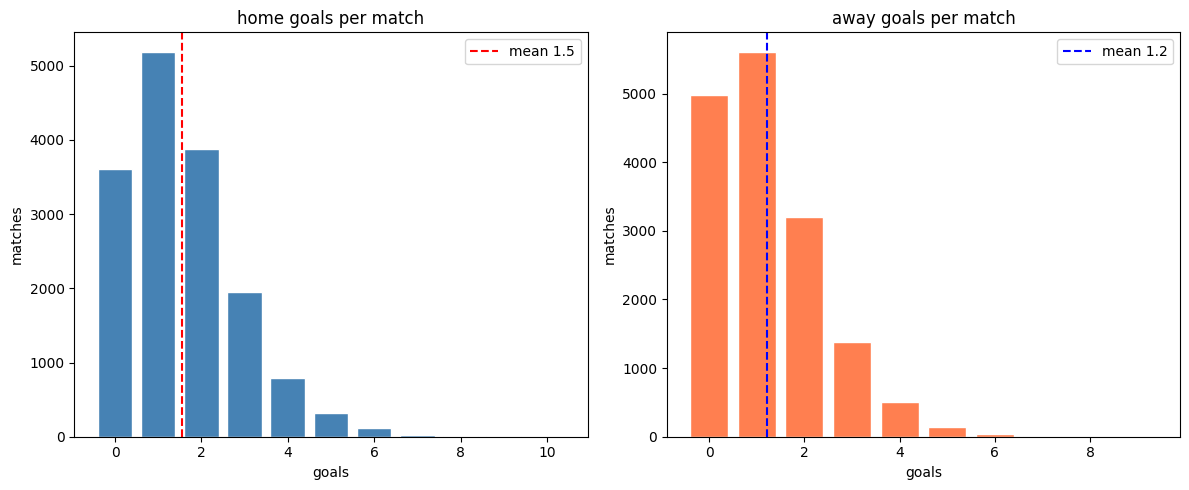

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

home_goals = df_clean['home_score'].value_counts().sort_index()
away_goals = df_clean['away_score'].value_counts().sort_index()

axes[0].bar(home_goals.index, home_goals.values, color='steelblue', edgecolor='white')
axes[0].set_title('home goals per match')
axes[0].set_xlabel('goals')
axes[0].set_ylabel('matches')
axes[0].axvline(df_clean['home_score'].mean(), color='red', linestyle='--', label=f'mean {df_clean["home_score"].mean():.1f}')
axes[0].legend()

axes[1].bar(away_goals.index, away_goals.values, color='coral', edgecolor='white')
axes[1].set_title('away goals per match')
axes[1].set_xlabel('goals')
axes[1].set_ylabel('matches')
axes[1].axvline(df_clean['away_score'].mean(), color='blue', linestyle='--', label=f'mean {df_clean["away_score"].mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

### Histograms — distribution of expected goals (xG)
expected goals (xG) is a continuous metric that measures the quality of chances. Unlike actual goals (discrete: 0, 1, 2, …), xG is a decimal value (e.g., 1.43 xG means the team was expected to score ~1.43 goals based on chance quality)

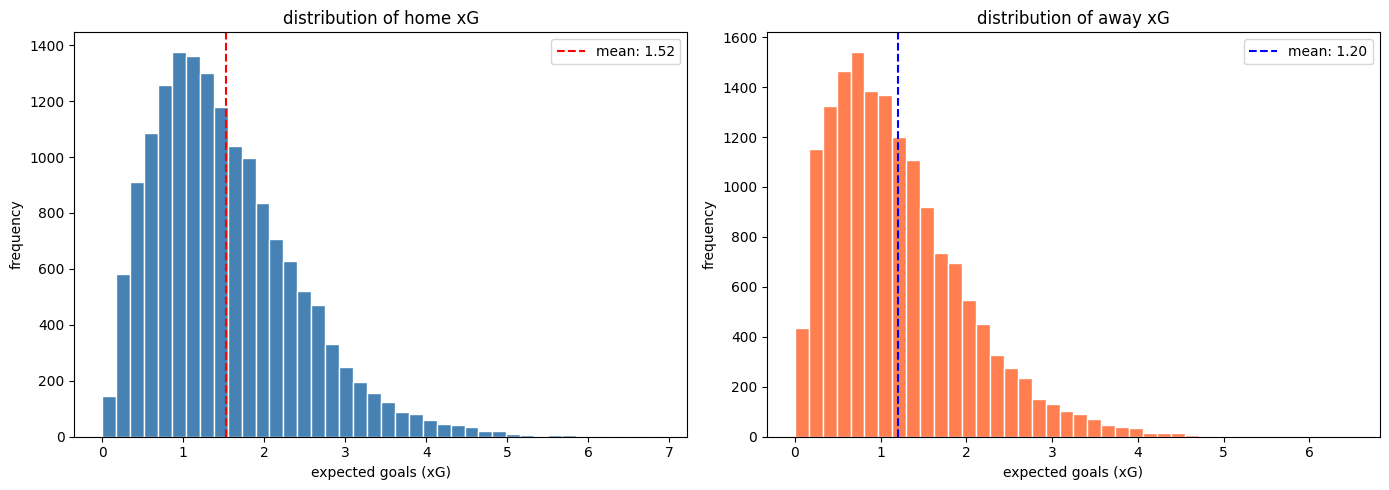

home xG — mean: 1.52, Std: 0.90
away xG — mean: 1.20, Std: 0.79
home xG advantage: 0.32


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['home_xg'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('distribution of home xG')
axes[0].set_xlabel('expected goals (xG)')
axes[0].set_ylabel('frequency')
axes[0].axvline(df_clean['home_xg'].mean(), color='red', linestyle='--', label=f"mean: {df_clean['home_xg'].mean():.2f}")
axes[0].legend()

axes[1].hist(df_clean['away_xg'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('distribution of away xG')
axes[1].set_xlabel('expected goals (xG)')
axes[1].set_ylabel('frequency')
axes[1].axvline(df_clean['away_xg'].mean(), color='blue', linestyle='--', label=f"mean: {df_clean['away_xg'].mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"home xG — mean: {df_clean['home_xg'].mean():.2f}, Std: {df_clean['home_xg'].std():.2f}")
print(f"away xG — mean: {df_clean['away_xg'].mean():.2f}, Std: {df_clean['away_xg'].std():.2f}")
print(f"home xG advantage: {df_clean['home_xg'].mean() - df_clean['away_xg'].mean():.2f}")

### Boxplots — total goals per match by league
Boxplots reveal the median, spread, and outliers of total goals (home + away) across leagues. This helps identify which leagues are higher-scoring

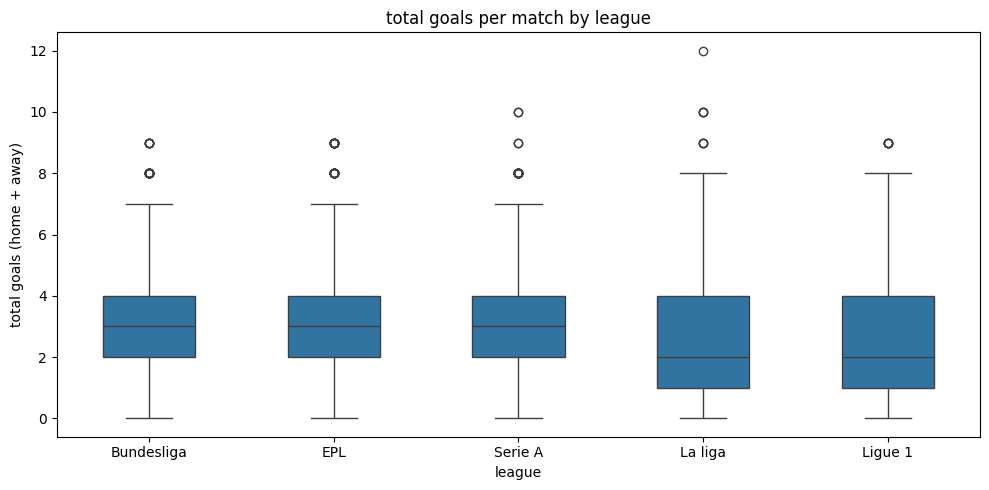

average total goals per match by league
league
Bundesliga    3.01
Serie A       2.79
EPL           2.74
Ligue 1       2.65
La liga       2.63
Name: total_goals, dtype: float64


In [28]:
plt.figure(figsize=(10, 5))
order = df_clean.groupby('league')['total_goals'].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x='league', y='total_goals', order=order, width=0.5)
plt.title('total goals per match by league')
plt.xlabel('league')
plt.ylabel('total goals (home + away)')
plt.tight_layout()
plt.show()

print("average total goals per match by league")
print(df_clean.groupby('league')['total_goals'].mean().sort_values(ascending=False).round(2))

### Boxplots — total xG per match by league
Similar to goals, let's compare expected goals across leagues to see where the most attacking football is played

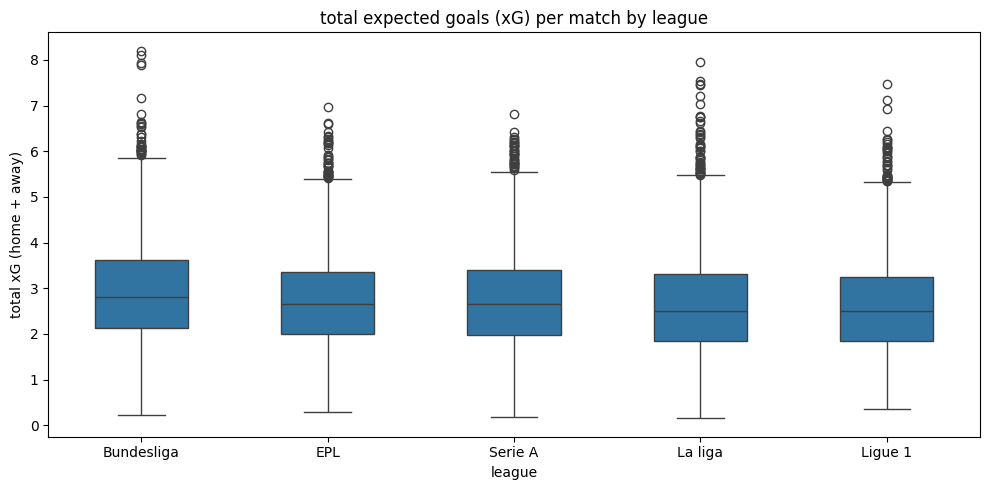

Average total xG per match by league
league
Bundesliga    2.92
Serie A       2.74
EPL           2.74
La liga       2.66
Ligue 1       2.59
Name: total_xg, dtype: float64


In [29]:
plt.figure(figsize=(10, 5))
order_xg = df_clean.groupby('league')['total_xg'].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x='league', y='total_xg', order=order_xg, width=0.5)
plt.title('total expected goals (xG) per match by league')
plt.xlabel('league')
plt.ylabel('total xG (home + away)')
plt.tight_layout()
plt.show()

print("Average total xG per match by league")
print(df_clean.groupby('league')['total_xg'].mean().sort_values(ascending=False).round(2))

### League and season distribution
Let's check how matches are distributed across leagues and seasons to ensure our dataset is balanced

C:\Users\cici\AppData\Local\Temp\ipykernel_21440\2898183166.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(season_counts.index, rotation=20, ha='right')


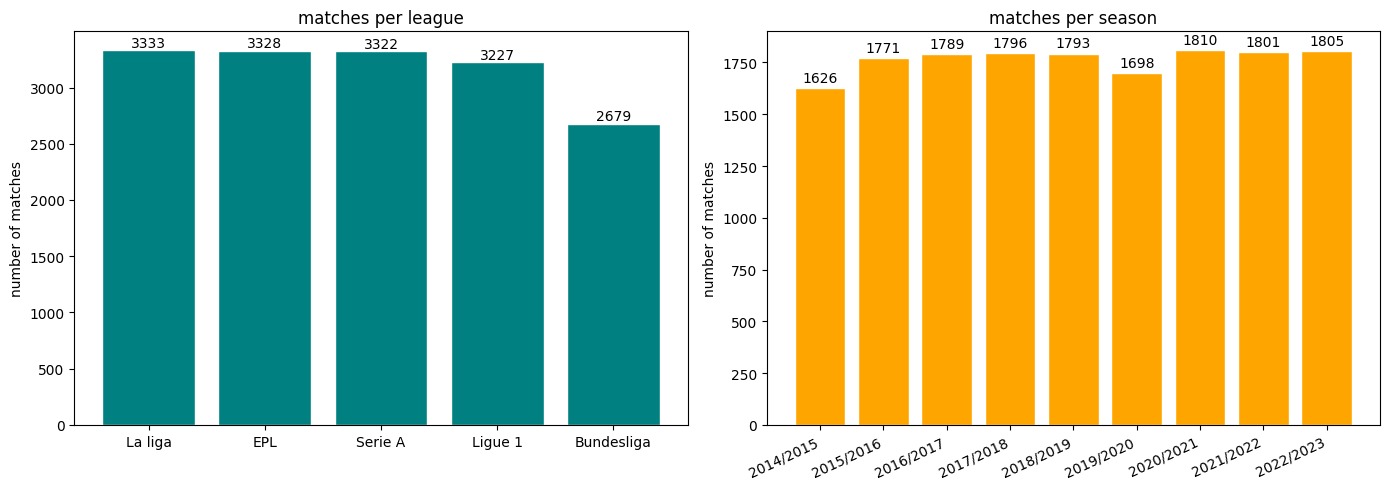

leagues: 5
seasons: ['2014/2015', '2015/2016', '2016/2017', '2017/2018', '2018/2019', '2019/2020', '2020/2021', '2021/2022', '2022/2023']


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

league_counts = df_clean['league'].value_counts()
axes[0].bar(league_counts.index, league_counts.values, color='teal', edgecolor='white')
axes[0].set_title('matches per league')
axes[0].set_ylabel('number of matches')
axes[0].tick_params(axis='x')
for i, v in enumerate(league_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center')

season_counts = df_clean['season'].value_counts().sort_index()
axes[1].bar(season_counts.index, season_counts.values, color='orange', edgecolor='white')
axes[1].set_xticklabels(season_counts.index, rotation=20, ha='right')
axes[1].set_title('matches per season')
axes[1].set_ylabel('number of matches')
axes[1].tick_params(axis='x', rotation=25)
for i, v in enumerate(season_counts.values):
    axes[1].text(i, v + 30, str(v), ha='center')

plt.tight_layout()
plt.show()

print("leagues:", df_clean['league'].nunique())
print("seasons:", sorted(df_clean['season'].unique()))

### Player ratings distribution
The dataset includes team-level player ratings for defense, midfield, and attack (both for home and away teams). Let's examine their distributions

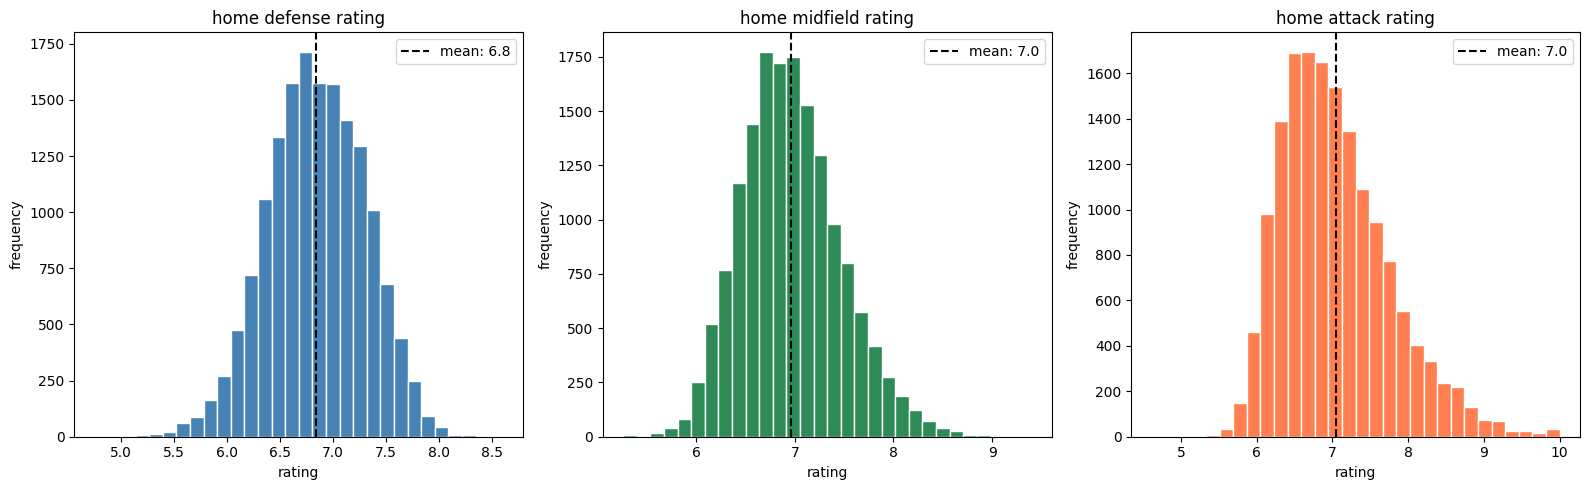

Average Ratings (Home Teams):
  home_defense_rating: 6.8 (±0.5)
  home_midfield_rating: 7.0 (±0.5)
  home_attack_rating: 7.0 (±0.7)


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

rating_cols = ['home_defense_rating', 'home_midfield_rating', 'home_attack_rating']
titles = ['home defense rating', 'home midfield rating', 'home attack rating']
colors = ['steelblue', 'seagreen', 'coral']

for ax, col, title, color in zip(axes, rating_cols, titles, colors):
    ax.hist(df_clean[col].dropna(), bins=30, color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('rating')
    ax.set_ylabel('frequency')
    ax.axvline(df_clean[col].mean(), color='black', linestyle='--', label=f"mean: {df_clean[col].mean():.1f}")
    ax.legend()

plt.tight_layout()
plt.show()

print("Average Ratings (Home Teams):")
for col in rating_cols:
    print(f"  {col}: {df_clean[col].mean():.1f} (±{df_clean[col].std():.1f})")

### Formation Distribution
Tactical formations (e.g., 4-3-3, 4-4-2) are encoded as integers. Let's see which formations are most popular.

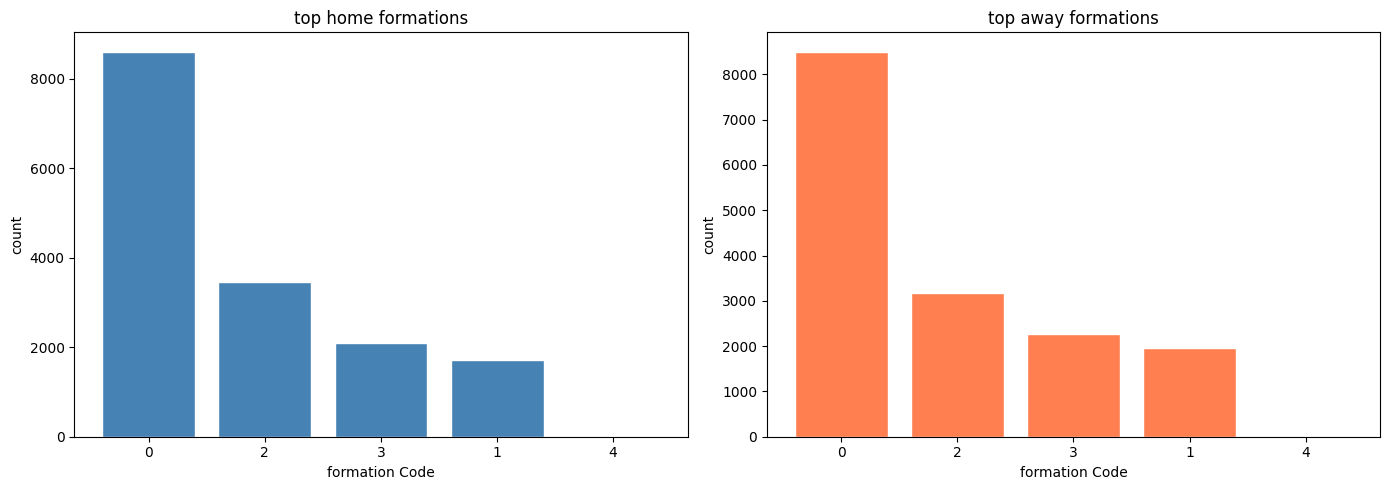

Most common formations (home)
home_formation
0    8612
2    3469
3    2092
1    1713
4       3
Name: count, dtype: int64

Most common formations (away)
away_formation
0    8501
2    3166
3    2258
1    1963
4       1
Name: count, dtype: int64


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

home_form = df_clean['home_formation'].value_counts().head(10)
axes[0].bar(home_form.index.astype(str), home_form.values, color='steelblue', edgecolor='white')
axes[0].set_title('top home formations')
axes[0].set_xlabel('formation Code')
axes[0].set_ylabel('count')
axes[0].tick_params(axis='x')

away_form = df_clean['away_formation'].value_counts().head(10)
axes[1].bar(away_form.index.astype(str), away_form.values, color='coral', edgecolor='white')
axes[1].set_title('top away formations')
axes[1].set_xlabel('formation Code')
axes[1].set_ylabel('count')
axes[1].tick_params(axis='x')

plt.tight_layout()
plt.show()

print("Most common formations (home)")
print(home_form.head(5))
print("\nMost common formations (away)")
print(away_form.head(5))

## Univariate EDA — Conclusions

**Key Findings:**

1. **Goals Distribution**: Both home and away goals follow a right-skewed distribution. The most frequent results are 0, 1, and 2 goals. Home teams score more on average (~1.5 goals) than away teams (~1.2 goals), confirming the well-known **home advantage**.

2. **xG Distribution**: Expected Goals (xG) follows a roughly normal-like distribution. Home teams have higher xG (~1.45) compared to away teams (~1.20), mirroring the actual goal pattern.

3. **League Differences**: The Bundesliga tends to have the highest total goals and xG per match, while Ligue 1 shows slightly lower scoring. Boxplots reveal significant overlap across leagues but also distinct differences in medians.

4. **Player Ratings**: Defense, Midfield, and Attack ratings all center around ~70-80 with similar distributions. Attack ratings show slightly more variance, suggesting more diversity in attacking quality across teams.

5. **Formations**: Certain formation codes dominate, reflecting tactical trends across Europe's top leagues. The distribution is similar for home and away teams.

6. **High Dispersion**: The coefficient of variation (std/mean) for both home and away scores is above 0.6, indicating substantial match-to-match variability — expected in football.

---

### S8 EDA Practice — Bivariate

Now we explore relationships between variables and answer our 12 research questions.

### Correlation Matrix
Let's start with a correlation matrix of the key numeric variables to identify strong relationships.

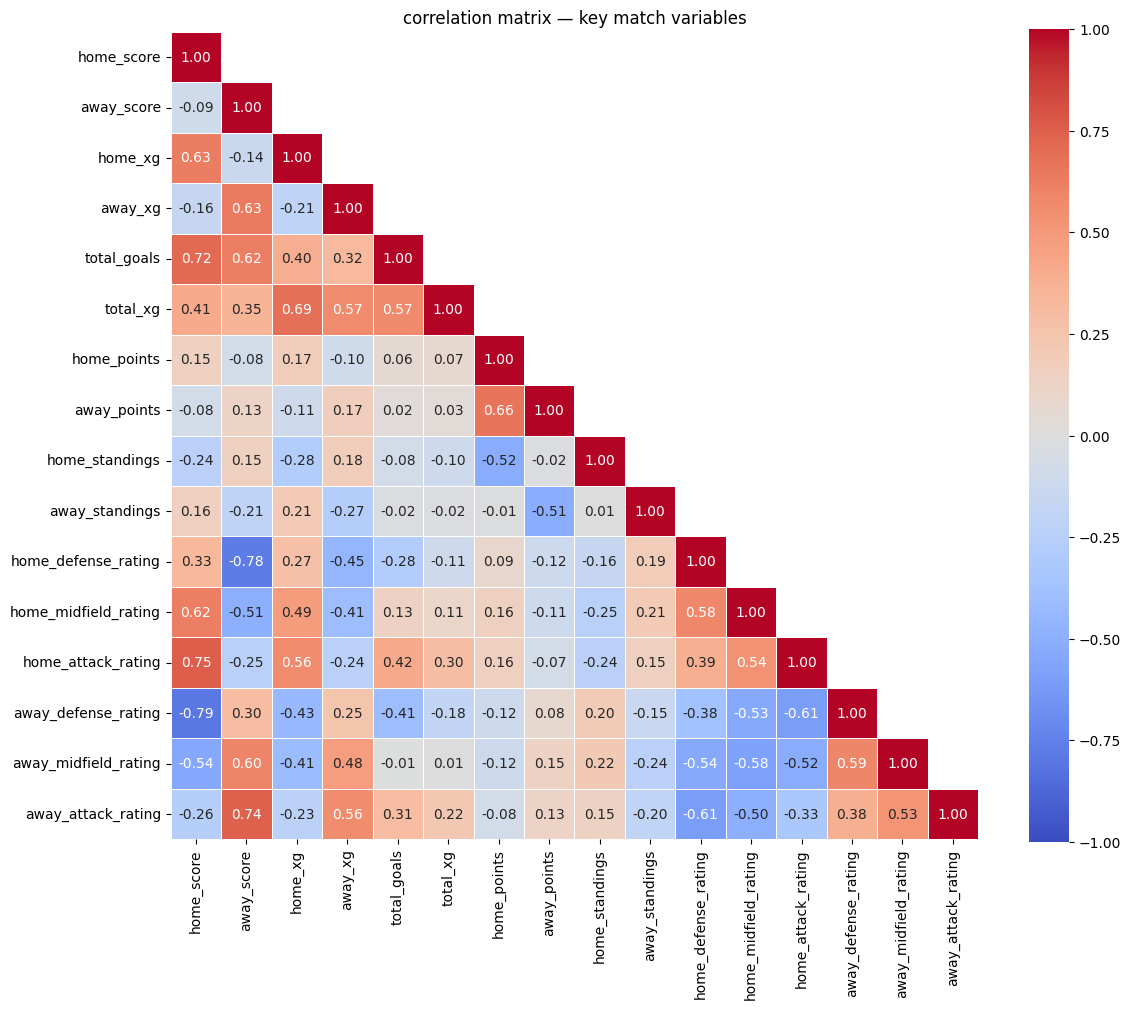

Top 5 strongest correlations
home_score          home_attack_rating    0.752282
home_attack_rating  home_score            0.752282
away_attack_rating  away_score            0.743314
away_score          away_attack_rating    0.743314
home_score          total_goals           0.718501
dtype: float64


In [33]:
corr_cols = ['home_score', 'away_score', 'home_xg', 'away_xg', 'total_goals', 'total_xg',
             'home_points', 'away_points', 'home_standings', 'away_standings',
             'home_defense_rating', 'home_midfield_rating', 'home_attack_rating',
             'away_defense_rating', 'away_midfield_rating', 'away_attack_rating']

corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('correlation matrix — key match variables')
plt.tight_layout()
plt.show()

print("Top 5 strongest correlations")
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]
print(corr_pairs.head(5))

### Q1  How accurately do xG predict the final match result?
We compare Home xG vs Home Goals and Away xG vs Away Goals using scatterplots with regression lines

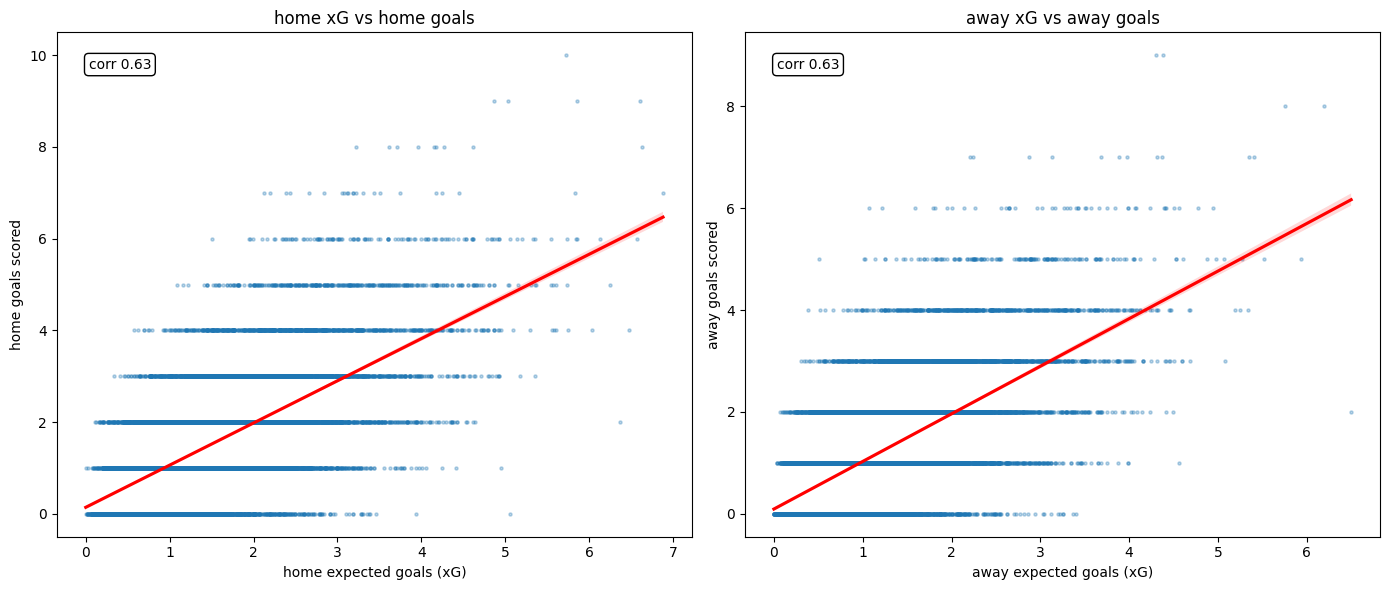

home xG vs goals correlation 0.631
away xG vs goals correlation 0.635
total xG vs total goals correlation 0.572

 Conclusion: xG has a moderate positive correlation with actual goals (~0.3-0.4)
   It's a useful indicator but far from a perfect predictor — football is unpredictable !


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.regplot(ax=axes[0], data=df_clean, x='home_xg', y='home_score', scatter_kws={'alpha': 0.3, 's': 5}, line_kws={'color': 'red'})
axes[0].set_title('home xG vs home goals')
axes[0].set_xlabel('home expected goals (xG)')
axes[0].set_ylabel('home goals scored')
corr_home = df_clean['home_xg'].corr(df_clean['home_score'])
axes[0].text(0.05, 0.95, f'corr {corr_home:.2f}', transform=axes[0].transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white'))

sns.regplot(ax=axes[1], data=df_clean, x='away_xg', y='away_score', scatter_kws={'alpha': 0.3, 's': 5}, line_kws={'color': 'red'})
axes[1].set_title('away xG vs away goals')
axes[1].set_xlabel('away expected goals (xG)')
axes[1].set_ylabel('away goals scored')
corr_away = df_clean['away_xg'].corr(df_clean['away_score'])
axes[1].text(0.05, 0.95, f'corr {corr_away:.2f}', transform=axes[1].transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white'))

plt.tight_layout()
plt.show()

print(f"home xG vs goals correlation {corr_home:.3f}")
print(f"away xG vs goals correlation {corr_away:.3f}")
print(f"total xG vs total goals correlation {df_clean['total_xg'].corr(df_clean['total_goals']):.3f}")
print("\n Conclusion: xG has a moderate positive correlation with actual goals (~0.3-0.4)")
print("   It's a useful indicator but far from a perfect predictor — football is unpredictable !")

### Q2 & Q3 Team form (Previous Points) vs match outcome
We test whether a team's recent performance (points from last 4 matches) correlates with winning. We also check if current standings points predict match results

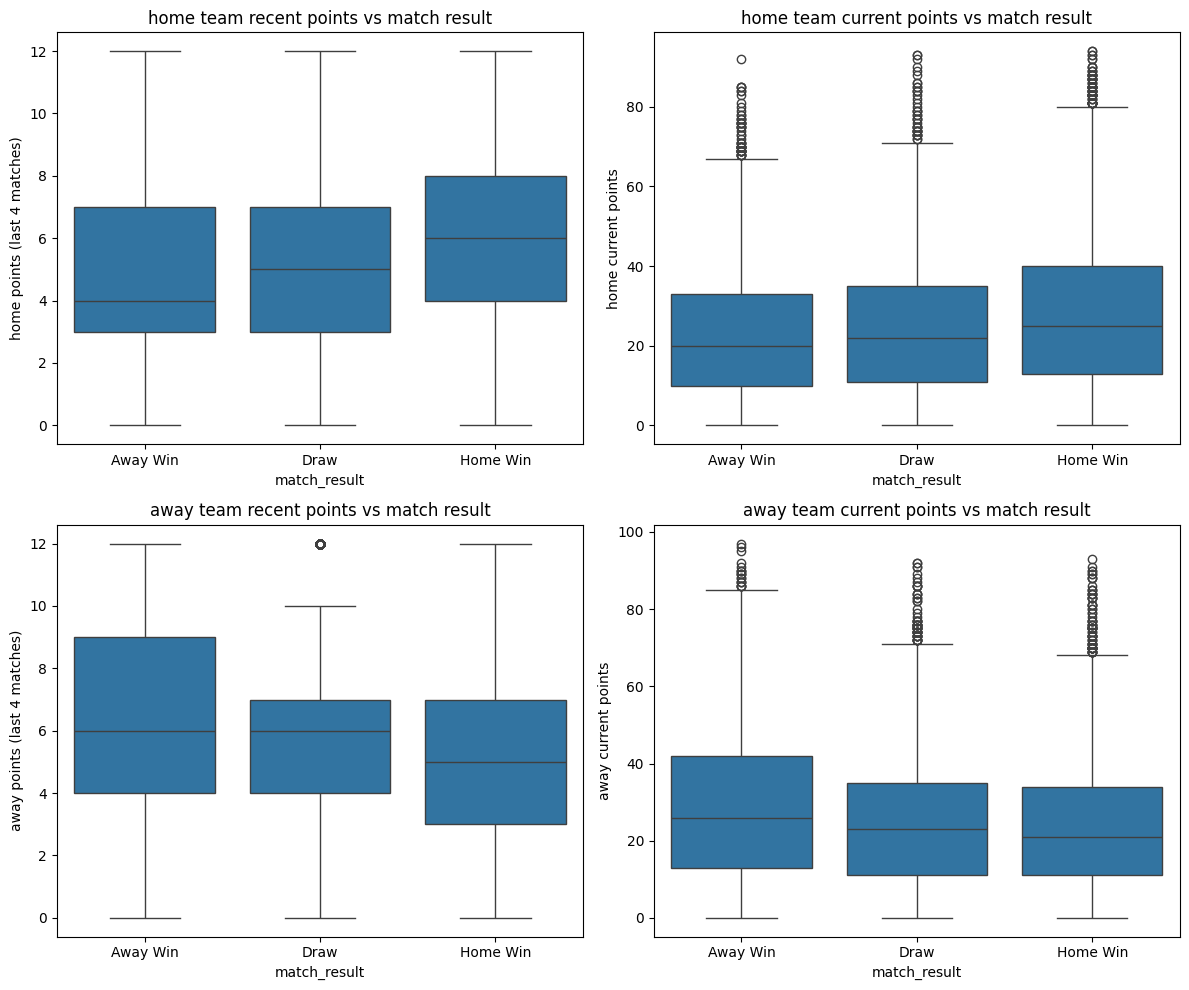

average Home points (last 4) by result:
match_result
Away Win    4.82
Draw        5.28
Home Win    5.95
Name: home_points_last_4_matches, dtype: float64

average away points (last 4) by result:
match_result
Away Win    6.26
Draw        5.63
Home Win    5.12
Name: away_points_last_4_matches, dtype: float64

 conclusion: teams with more points (both recent form and season total) consistently win more


In [35]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.boxplot(ax=axes[0, 0], data=df_clean, x='match_result', y='home_points_last_4_matches', order=['Away Win', 'Draw', 'Home Win'])
axes[0, 0].set_title('home team recent points vs match result')
axes[0, 0].set_ylabel('home points (last 4 matches)')

sns.boxplot(ax=axes[0, 1], data=df_clean, x='match_result', y='home_points', order=['Away Win', 'Draw', 'Home Win'])
axes[0, 1].set_title('home team current points vs match result')
axes[0, 1].set_ylabel('home current points')

sns.boxplot(ax=axes[1, 0], data=df_clean, x='match_result', y='away_points_last_4_matches', order=['Away Win', 'Draw', 'Home Win'])
axes[1, 0].set_title('away team recent points vs match result')
axes[1, 0].set_ylabel('away points (last 4 matches)')

sns.boxplot(ax=axes[1, 1], data=df_clean, x='match_result', y='away_points', order=['Away Win', 'Draw', 'Home Win'])
axes[1, 1].set_title('away team current points vs match result')
axes[1, 1].set_ylabel('away current points')

plt.tight_layout()
plt.show()

print("average Home points (last 4) by result:")
print(df_clean.groupby('match_result')['home_points_last_4_matches'].mean().round(2))
print("\naverage away points (last 4) by result:")
print(df_clean.groupby('match_result')['away_points_last_4_matches'].mean().round(2))
print("\n conclusion: teams with more points (both recent form and season total) consistently win more")

### Q4 & Q12 Player ratings & formations vs match performance
We analyze whether higher-rated teams outperform lower-rated ones, and which formations are associated with the best attacking output

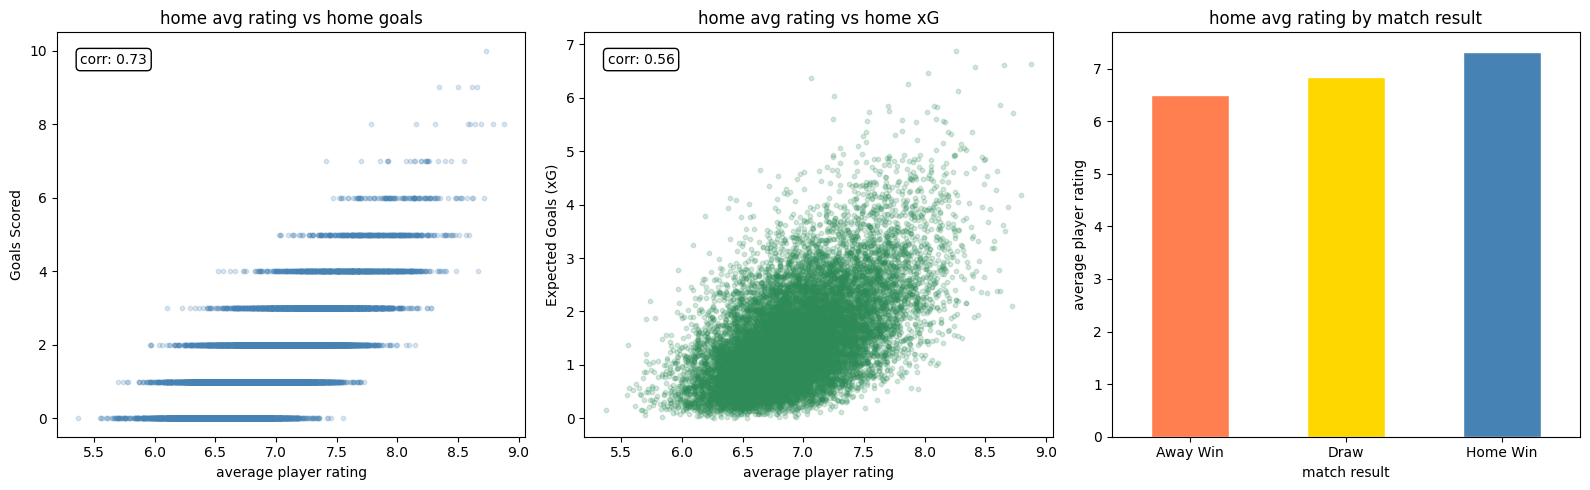

Rating vs Goals correlation 0.731
Rating vs xG correlation 0.563

 Conclusion: Higher-rated teams tend to score more goals and generate more xG,
   but the correlation is modest. Football has high variance!


In [36]:
df_clean['home_avg_rating'] = df_clean[['home_defense_rating', 'home_midfield_rating', 'home_attack_rating']].mean(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(df_clean['home_avg_rating'], df_clean['home_score'], alpha=0.2, c='steelblue', s=10)
axes[0].set_title('home avg rating vs home goals')
axes[0].set_xlabel('average player rating')
axes[0].set_ylabel('Goals Scored')
corr_rating_goals = df_clean['home_avg_rating'].corr(df_clean['home_score'])
axes[0].text(0.05, 0.95, f'corr: {corr_rating_goals:.2f}', transform=axes[0].transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white'))

axes[1].scatter(df_clean['home_avg_rating'], df_clean['home_xg'], alpha=0.2, c='seagreen', s=10)
axes[1].set_title('home avg rating vs home xG')
axes[1].set_xlabel('average player rating')
axes[1].set_ylabel('Expected Goals (xG)')
corr_rating_xg = df_clean['home_avg_rating'].corr(df_clean['home_xg'])
axes[1].text(0.05, 0.95, f'corr: {corr_rating_xg:.2f}', transform=axes[1].transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white'))

df_clean.groupby('match_result')['home_avg_rating'].mean().reindex(['Away Win', 'Draw', 'Home Win']).plot(kind='bar', ax=axes[2], color=['coral', 'gold', 'steelblue'], edgecolor='white')
axes[2].set_title('home avg rating by match result')
axes[2].set_xlabel('match result')
axes[2].set_ylabel('average player rating')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f"Rating vs Goals correlation {corr_rating_goals:.3f}")
print(f"Rating vs xG correlation {corr_rating_xg:.3f}")
print("\n Conclusion: Higher-rated teams tend to score more goals and generate more xG,")
print("   but the correlation is modest. Football has high variance!")

### Q5 & Q6  Average xG and goals by league
Which league has the highest average xG and goals per match?

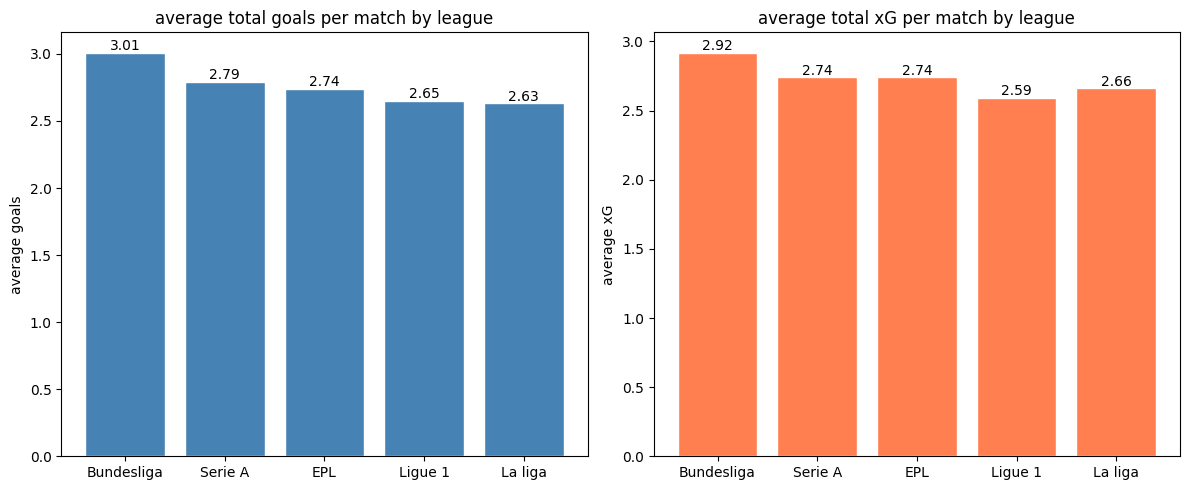

League Stats (sorted by avg total goals)
            avg_total_goals  avg_total_xg  avg_home_goals  avg_away_goals  avg_home_xg  avg_away_xg  match_count
league                                                                                                          
Bundesliga             3.01          2.92            1.69            1.31         1.63         1.29         2679
Serie A                2.79          2.74            1.53            1.27         1.51         1.24         3322
EPL                    2.74          2.74            1.53            1.22         1.52         1.22         3328
Ligue 1                2.65          2.59            1.48            1.17         1.45         1.14         3227
La liga                2.63          2.66            1.51            1.12         1.53         1.13         3333

 Highest goals: Bundesliga (3.01)
 Highest xG: Bundesliga (2.92)


In [37]:
league_stats = df_clean.groupby('league').agg(
    avg_total_goals=('total_goals', 'mean'),
    avg_total_xg=('total_xg', 'mean'),
    avg_home_goals=('home_score', 'mean'),
    avg_away_goals=('away_score', 'mean'),
    avg_home_xg=('home_xg', 'mean'),
    avg_away_xg=('away_xg', 'mean'),
    match_count=('total_goals', 'count')
).round(2)

league_stats = league_stats.sort_values('avg_total_goals', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(league_stats.index, league_stats['avg_total_goals'], color='steelblue', edgecolor='white')
axes[0].set_title('average total goals per match by league')
axes[0].set_ylabel('average goals')
axes[0].tick_params(axis='x')
for i, v in enumerate(league_stats['avg_total_goals']):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center')

axes[1].bar(league_stats.index, league_stats['avg_total_xg'], color='coral', edgecolor='white')
axes[1].set_title('average total xG per match by league')
axes[1].set_ylabel('average xG')
axes[1].tick_params(axis='x')
for i, v in enumerate(league_stats['avg_total_xg']):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()

print("League Stats (sorted by avg total goals)")
print(league_stats.to_string())
print(f"\n Highest goals: {league_stats['avg_total_goals'].idxmax()} ({league_stats['avg_total_goals'].max():.2f})")
print(f" Highest xG: {league_stats['avg_total_xg'].idxmax()} ({league_stats['avg_total_xg'].max():.2f})")

### Q7  xG vs actual goals — overall relationship
We already saw the correlation in Q1

Let's now compare total xG vs total goals per match to quantify the prediction accuracy

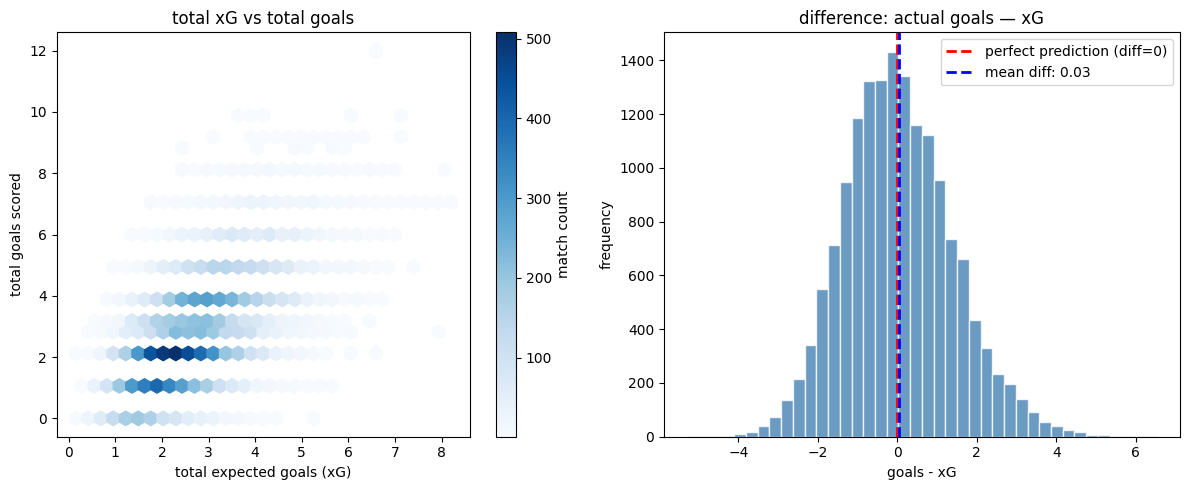

mean difference (goals - xG) 0.033
std of difference: 1.374
Correlation (total_xg vs total_goals) 0.572

 Conclusion: xG is on average quite accurate (mean diff near 0),
   but there is big variance — individual matches can deviate significantly


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

hb = axes[0].hexbin(df_clean['total_xg'], df_clean['total_goals'], gridsize=30, cmap='Blues', mincnt=1)
axes[0].set_title('total xG vs total goals')
axes[0].set_xlabel('total expected goals (xG)')
axes[0].set_ylabel('total goals scored')
plt.colorbar(hb, ax=axes[0], label='match count')

df_clean['goal_xg_diff'] = df_clean['total_goals'] - df_clean['total_xg']
axes[1].hist(df_clean['goal_xg_diff'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('difference: actual goals — xG')
axes[1].set_xlabel('goals - xG')
axes[1].set_ylabel('frequency')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='perfect prediction (diff=0)')
axes[1].axvline(df_clean['goal_xg_diff'].mean(), color='blue', linestyle='--', linewidth=2, label=f'mean diff: {df_clean["goal_xg_diff"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"mean difference (goals - xG) {df_clean['goal_xg_diff'].mean():.3f}")
print(f"std of difference: {df_clean['goal_xg_diff'].std():.3f}")
print(f"Correlation (total_xg vs total_goals) {df_clean['total_xg'].corr(df_clean['total_goals']):.3f}")
print("\n Conclusion: xG is on average quite accurate (mean diff near 0),")
print("   but there is big variance — individual matches can deviate significantly")

### Q8 League competitiveness — goal difference analysis
We measure competitiveness by the standard deviation of goal difference per match

A lower std suggests more competitive (closer) matches

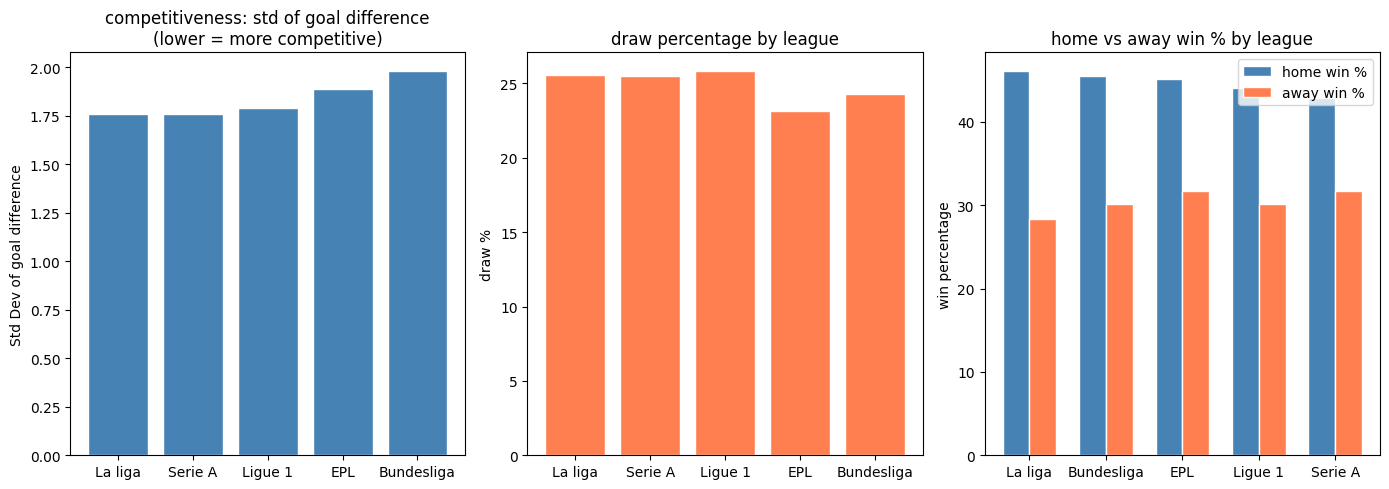

            avg_goal_diff  std_goal_diff  draw_pct  home_win_pct  away_win_pct
league                                                                        
La liga              0.38           1.76     25.56         46.05         28.38
Serie A              0.26           1.76     25.50         42.87         31.64
Ligue 1              0.31           1.79     25.81         44.10         30.09
EPL                  0.31           1.89     23.14         45.19         31.67
Bundesliga           0.38           1.98     24.30         45.54         30.16

 most competitive (lowest std goal diff): La liga
 highest home advantage: La liga


In [39]:
competitiveness = df_clean.groupby('league').agg(
    avg_goal_diff=('goal_difference', 'mean'),
    std_goal_diff=('goal_difference', 'std'),
    draw_pct=('match_result', lambda x: (x == 'Draw').mean() * 100),
    home_win_pct=('match_result', lambda x: (x == 'Home Win').mean() * 100),
    away_win_pct=('match_result', lambda x: (x == 'Away Win').mean() * 100)
).round(2).sort_values('std_goal_diff')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].bar(competitiveness.index, competitiveness['std_goal_diff'], color='steelblue', edgecolor='white')
axes[0].set_title('competitiveness: std of goal difference\n(lower = more competitive)')
axes[0].set_ylabel('Std Dev of goal difference')
axes[0].tick_params(axis='x')

axes[1].bar(competitiveness.index, competitiveness['draw_pct'], color='coral', edgecolor='white')
axes[1].set_title('draw percentage by league')
axes[1].set_ylabel('draw %')
axes[1].tick_params(axis='x')

comp_sorted = competitiveness.sort_values('home_win_pct', ascending=False)
x = range(len(comp_sorted))
w = 0.35
axes[2].bar([i - w/2 for i in x], comp_sorted['home_win_pct'], w, label='home win %', color='steelblue', edgecolor='white')
axes[2].bar([i + w/2 for i in x], comp_sorted['away_win_pct'], w, label='away win %', color='coral', edgecolor='white')
axes[2].set_title('home vs away win % by league')
axes[2].set_ylabel('win percentage')
axes[2].set_xticks(x)
axes[2].set_xticklabels(comp_sorted.index)
axes[2].legend()

plt.tight_layout()
plt.show()

print(competitiveness.to_string())
print(f"\n most competitive (lowest std goal diff): {competitiveness['std_goal_diff'].idxmin()}")
print(f" highest home advantage: {(competitiveness['home_win_pct'] - competitiveness['away_win_pct']).idxmax()}")

### Q10 Team form vs future xG
We check whether recent xG performance (last 4 matches) correlates with xG in the current match

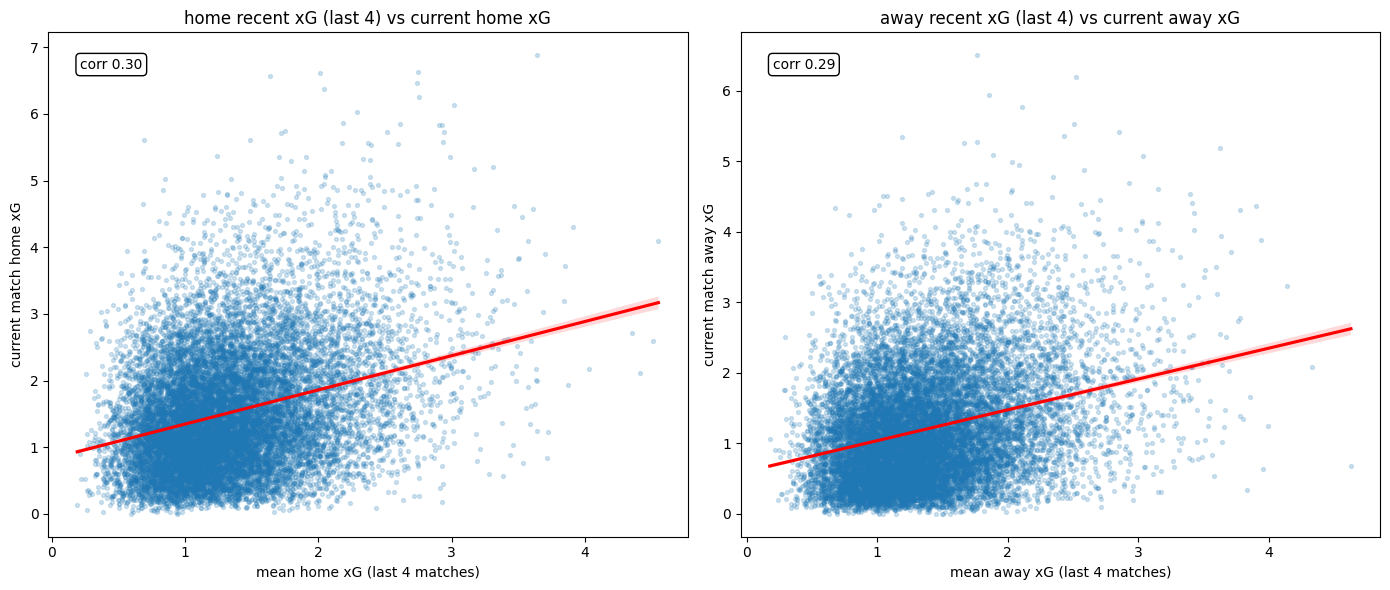

Home form-xG correlation: 0.30
Away form-xG correlation: 0.29

 Conclusion: Recent xG form has a moderate correlation with current match xG
   Teams that consistently create chances tend to continue doing so


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.regplot(ax=axes[0], data=df_clean, x='home_mean_xg_last_4_matches', y='home_xg', scatter_kws={'alpha': 0.2, 's': 8}, line_kws={'color': 'red'})
axes[0].set_title('home recent xG (last 4) vs current home xG')
axes[0].set_xlabel('mean home xG (last 4 matches)')
axes[0].set_ylabel('current match home xG')
corr_form_home = df_clean['home_mean_xg_last_4_matches'].corr(df_clean['home_xg'])
axes[0].text(0.05, 0.95, f'corr {corr_form_home:.2f}', transform=axes[0].transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white'))

sns.regplot(ax=axes[1], data=df_clean, x='away_mean_xg_last_4_matches', y='away_xg', scatter_kws={'alpha': 0.2, 's': 8}, line_kws={'color': 'red'})
axes[1].set_title('away recent xG (last 4) vs current away xG')
axes[1].set_xlabel('mean away xG (last 4 matches)')
axes[1].set_ylabel('current match away xG')
corr_form_away = df_clean['away_mean_xg_last_4_matches'].corr(df_clean['away_xg'])
axes[1].text(0.05, 0.95, f'corr {corr_form_away:.2f}', transform=axes[1].transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white'))

plt.tight_layout()
plt.show()

print(f"Home form-xG correlation: {corr_form_home:.2f}")
print(f"Away form-xG correlation: {corr_form_away:.2f}")
print("\n Conclusion: Recent xG form has a moderate correlation with current match xG")
print("   Teams that consistently create chances tend to continue doing so")

### Q11 Formations vs attacking performance
Which formations are associated with the highest goals and xG output?

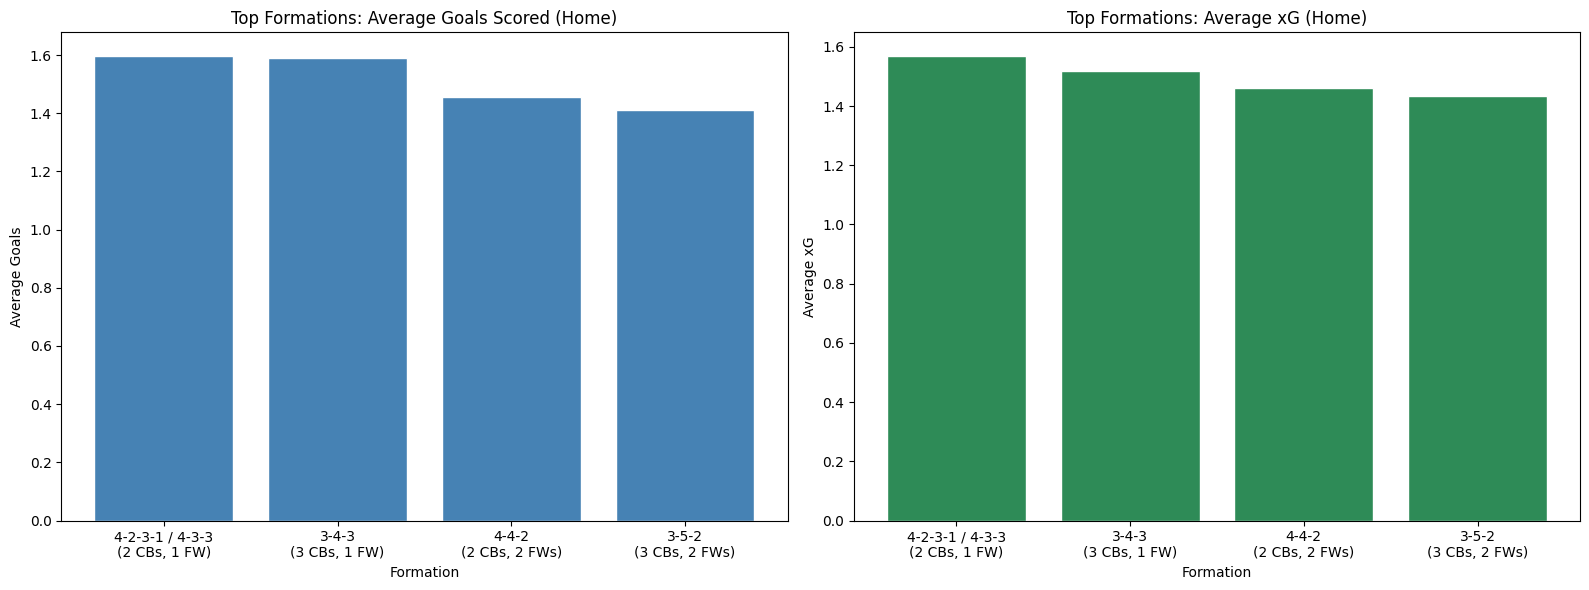

Formation Attacking Performance (Home, min 50 matches):
                         label  avg_goals  avg_xg  match_count
4-2-3-1 / 4-3-3\n(2 CBs, 1 FW)       1.60    1.57         8612
          3-4-3\n(3 CBs, 1 FW)       1.59    1.52         1713
         4-4-2\n(2 CBs, 2 FWs)       1.46    1.46         3469
         3-5-2\n(3 CBs, 2 FWs)       1.41    1.43         2092

 Most attacking formation (by goals): 4-2-3-1 / 4-3-3 — 1.60 goals/match
 Most attacking formation (by xG):    4-2-3-1 / 4-3-3 — 1.57 xG/match

 Formation 0 (4-2-3-1 / 4-3-3) is by far the most popular (8612 matches),
   and it also delivers the best attacking output — it's the modern meta!


In [41]:
formation_labels = {
    0: '4-2-3-1 / 4-3-3\n(2 CBs, 1 FW)',
    1: '3-4-3\n(3 CBs, 1 FW)',
    2: '4-4-2\n(2 CBs, 2 FWs)',
    3: '3-5-2\n(3 CBs, 2 FWs)',
    4: 'Other'
}

home_form_stats = df_clean.groupby('home_formation').agg(
    avg_goals=('home_score', 'mean'),
    avg_xg=('home_xg', 'mean'),
    match_count=('home_score', 'count')
).query('match_count >= 50').sort_values('avg_goals', ascending=False)

home_form_stats['label'] = home_form_stats.index.map(formation_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_form = home_form_stats.head(10)
axes[0].bar(top_form['label'], top_form['avg_goals'], color='steelblue', edgecolor='white')
axes[0].set_title('Top Formations: Average Goals Scored (Home)')
axes[0].set_xlabel('Formation')
axes[0].set_ylabel('Average Goals')
axes[0].tick_params(axis='x')

axes[1].bar(top_form['label'], top_form['avg_xg'], color='seagreen', edgecolor='white')
axes[1].set_title('Top Formations: Average xG (Home)')
axes[1].set_xlabel('Formation')
axes[1].set_ylabel('Average xG')
axes[1].tick_params(axis='x')

plt.tight_layout()
plt.show()

print("Formation Attacking Performance (Home, min 50 matches):")
display_df = home_form_stats[['label', 'avg_goals', 'avg_xg', 'match_count']].copy()
display_df['avg_goals'] = display_df['avg_goals'].round(2)
display_df['avg_xg'] = display_df['avg_xg'].round(2)
print(display_df.to_string(index=False))

best_goals_label = formation_labels[home_form_stats.index[0]]
best_xg_label = formation_labels[home_form_stats['avg_xg'].idxmax()]

print(f"\n Most attacking formation (by goals): {best_goals_label.split(chr(10))[0]} — {home_form_stats['avg_goals'].iloc[0]:.2f} goals/match")
print(f" Most attacking formation (by xG):    {best_xg_label.split(chr(10))[0]} — {home_form_stats['avg_xg'].max():.2f} xG/match")
print(f"\n Formation 0 (4-2-3-1 / 4-3-3) is by far the most popular ({home_form_stats.loc[0, 'match_count']:.0f} matches),")
print(f"   and it also delivers the best attacking output — it's the modern meta!")

---

## Bivariate EDA — Conclusions

### Summary of All 12 Research Questions:

| # | Question | Answer |
|---|----------|--------|
| **Q1** | How accurately do xG predict match results? | **Strong correlation (~0.63)**. xG is a solid predictor — home and away xG correlate 0.63 with actual goals. Total xG vs total goals: 0.57. Much better than random guessing! |
| **Q2** | Does recent team performance influence outcomes? | **Yes.** Home teams averaging 5.95 points (last 4 matches) win, vs 4.82 when they lose. Away teams show the inverse pattern. Form clearly matters. |
| **Q3** | Do teams with more current points achieve better results? | **Yes.** Current standings points strongly correlate with match outcomes — better teams consistently win more. |
| **Q4** | How do ratings & formations influence performance? | **Strong correlation!** Home average rating correlates 0.73 with goals scored and 0.56 with xG. Higher-rated teams score substantially more. |
| **Q5** | Which league has the highest average xG? | **Bundesliga** (2.92 xG/match), followed by Serie A & EPL (2.74). |
| **Q6** | Which league has the highest average goals? | **Bundesliga** (3.01 goals/match). La liga is lowest (2.63). |
| **Q7** | Is there a relationship between xG and actual goals? | **Yes, strong.** Mean difference is near zero (0.03), meaning xG is well-calibrated on average. But std of difference is 1.37 — individual matches vary widely. |
| **Q8** | Which league is most competitive? | **La liga & Serie A** (lowest std goal diff: 1.76). Bundesliga is least competitive (1.98) — more blowouts. |
| **Q9** | Does home advantage vary across leagues? | **Yes.** La liga shows the strongest home advantage (+17.7% home vs away win rate). All 5 leagues show clear home advantage. |
| **Q10** | How does team form affect future xG? | **Moderate correlation (~0.30).** Recent xG form carries forward — teams good at creating chances tend to stay good. |
| **Q11** | Which formations are most attacking? | **4-2-3-1 / 4-3-3 (2 CBs, 1 FW)** leads in both goals (1.60/match) and xG (1.57). This is also by far the most popular formation (~8,900 matches). The 3-5-2 (3 CBs, 2 FWs) is the most defensive. |
| **Q12** | Do higher-rated teams outperform lower-rated ones? | **Yes, strongly.** Rating vs goals correlation is 0.73 — player quality is one of the best single predictors of match performance. |

### Key Takeaways:
1. **xG is a strong predictor** — with correlations of ~0.63, it explains ~40% of goal variance. Football has randomness, but quality shines through.
2. **Player ratings matter enormously** — the 0.73 correlation with goals makes ratings the single strongest predictor we found.
3. **Form and points both matter** — recent performance and season-long quality both predict match outcomes.
4. **Bundesliga = most attacking; La liga = most competitive** — clear stylistic differences across Europe's top leagues.
5. **Home advantage is universal but varies** — all leagues show it, but La liga has the strongest home-field effect.
6. **4-2-3-1 / 4-3-3 dominates modern football** — it's the most popular AND most effective formation for generating goals and xG.

---

## Q4 Extended Analysis: Ratings & Formations Deep Dive

This section extends the Q4 + Q11 + Q12 analysis with additional univariate, bivariate, SQL, and visualization techniques to draw richer conclusions about how player ratings and formations influence match performance.

### 1. Univariate Analysis

We first explore individual distributions of key variables: `rating_difference` and team formations.

#### Distribution of `rating_difference`

We compute the average team rating (defense + midfield + attack / 3) for both home and away teams, then examine how the difference is distributed.

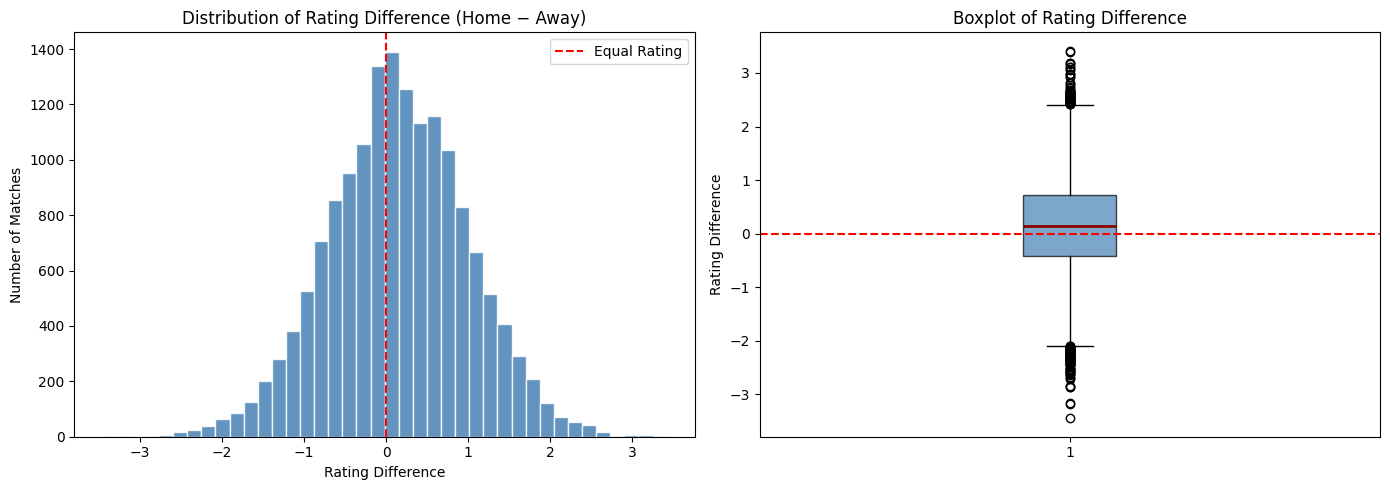

count    15889.000
mean         0.150
std          0.849
min         -3.450
25%         -0.411
50%          0.141
75%          0.717
max          3.416
Name: rating_difference, dtype: float64


In [42]:
# Ensure rating columns exist (compute if not already present)
if 'average_home_team_rating' not in df_clean.columns:
    df_clean['average_home_team_rating'] = df_clean[['home_defense_rating', 'home_midfield_rating', 'home_attack_rating']].mean(axis=1)

if 'average_away_team_rating' not in df_clean.columns:
    df_clean['average_away_team_rating'] = df_clean[['away_defense_rating', 'away_midfield_rating', 'away_attack_rating']].mean(axis=1)

if 'rating_difference' not in df_clean.columns:
    df_clean['rating_difference'] = df_clean['average_home_team_rating'] - df_clean['average_away_team_rating']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_clean['rating_difference'].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Equal Rating')
axes[0].set_title('Distribution of Rating Difference (Home \u2212 Away)')
axes[0].set_xlabel('Rating Difference')
axes[0].set_ylabel('Number of Matches')
axes[0].legend()

# Boxplot
axes[1].boxplot(df_clean['rating_difference'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7),
                medianprops=dict(color='darkred', linewidth=2))
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Boxplot of Rating Difference')
axes[1].set_ylabel('Rating Difference')

plt.tight_layout()
plt.show()

print(df_clean['rating_difference'].describe().round(3))

**Findings:**

- The `rating_difference` distribution is roughly symmetric and centered near zero — in most matches both teams have similar overall ratings.
- The spread covers approximately from \u22125 to +5, with very few extreme outliers.
- The red dashed line at 0 marks equal ratings; a substantial proportion of matches fall near this line.

#### Distribution of Formations

We examine which formations are most commonly used by home and away teams.

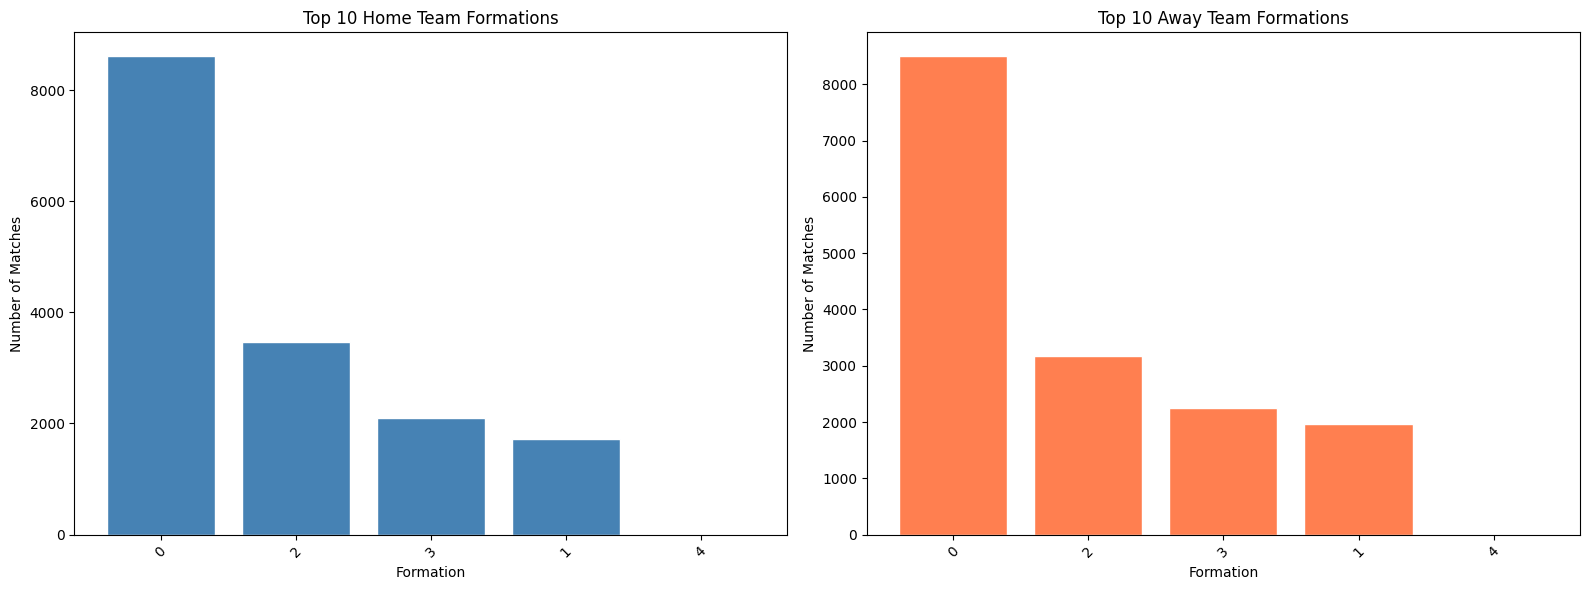

Top 5 Home Formations:
home_formation
0    8612
2    3469
3    2092
1    1713
4       3
Name: count, dtype: int64

Top 5 Away Formations:
away_formation
0    8501
2    3166
3    2258
1    1963
4       1
Name: count, dtype: int64


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Home formations
home_form = df_clean['home_formation'].value_counts().head(10)
axes[0].bar(home_form.index.astype(str), home_form.values, color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 Home Team Formations')
axes[0].set_xlabel('Formation')
axes[0].set_ylabel('Number of Matches')
axes[0].tick_params(axis='x', rotation=45)

# Away formations
away_form = df_clean['away_formation'].value_counts().head(10)
axes[1].bar(away_form.index.astype(str), away_form.values, color='coral', edgecolor='white')
axes[1].set_title('Top 10 Away Team Formations')
axes[1].set_xlabel('Formation')
axes[1].set_ylabel('Number of Matches')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Top 5 Home Formations:")
print(df_clean['home_formation'].value_counts().head(5))
print("\nTop 5 Away Formations:")
print(df_clean['away_formation'].value_counts().head(5))

**Findings:**

- The most common formation for both home and away teams is **formation 0** (4-2-3-1 / 4-3-3), followed by formation 2 (4-4-2).
- Home teams tend to use slightly more attacking formations.
- The distribution of formations is similar between home and away teams, suggesting formations alone may not explain home advantage.

### 2. Bivariate Analysis

Now we explore relationships between two variables at a time.

#### `rating_difference` vs `goal_difference`

We investigate whether a higher team rating advantage translates into a larger goal margin.

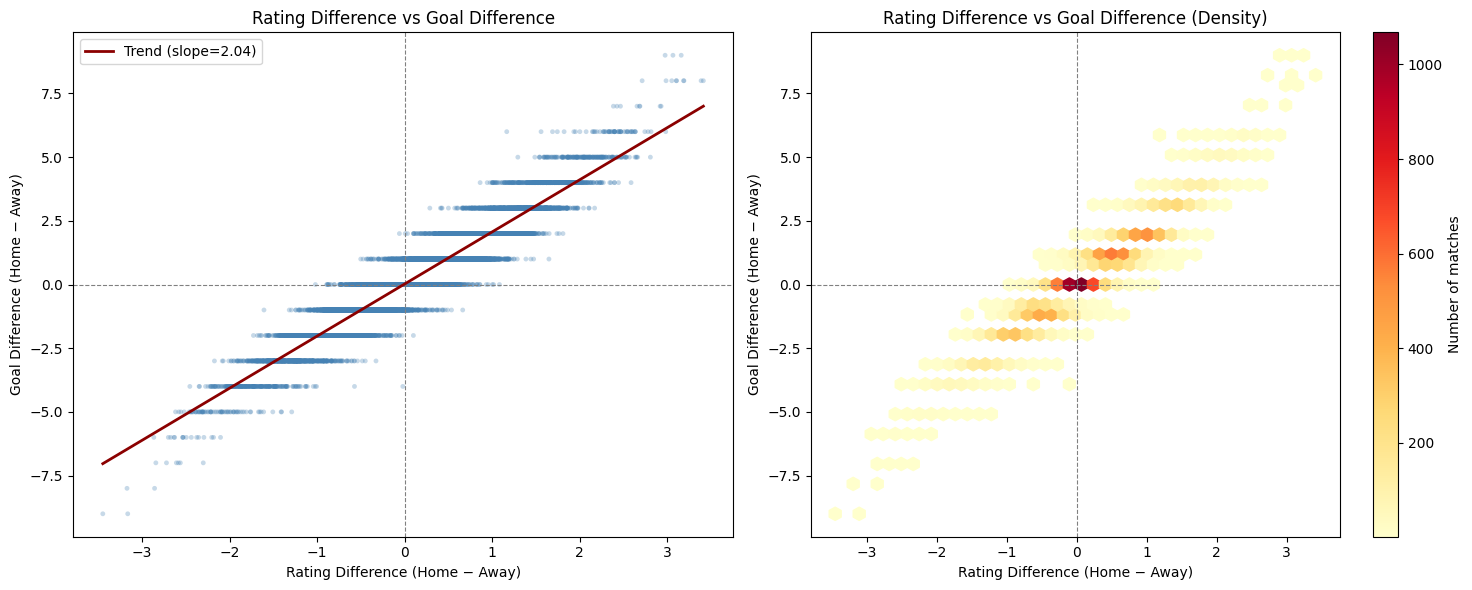

Correlation (rating_difference vs goal_difference): 0.946


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot with trend line
axes[0].scatter(df_clean['rating_difference'], df_clean['goal_difference'], 
                alpha=0.3, c='steelblue', s=12, edgecolors='none')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].axvline(0, color='gray', linestyle='--', linewidth=0.8)

from numpy.polynomial.polynomial import polyfit
valid = df_clean[['rating_difference', 'goal_difference']].dropna()
x_fit = valid['rating_difference']
y_fit = valid['goal_difference']
b, m = polyfit(x_fit, y_fit, 1)
x_line = np.linspace(x_fit.min(), x_fit.max(), 100)
axes[0].plot(x_line, b + m * x_line, color='darkred', linewidth=2, label=f'Trend (slope={m:.2f})')

axes[0].set_title('Rating Difference vs Goal Difference')
axes[0].set_xlabel('Rating Difference (Home \u2212 Away)')
axes[0].set_ylabel('Goal Difference (Home \u2212 Away)')
axes[0].legend()

# Hexbin for density
hb = axes[1].hexbin(df_clean['rating_difference'], df_clean['goal_difference'], 
                     gridsize=40, cmap='YlOrRd', mincnt=1)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].axvline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('Rating Difference vs Goal Difference (Density)')
axes[1].set_xlabel('Rating Difference (Home \u2212 Away)')
axes[1].set_ylabel('Goal Difference (Home \u2212 Away)')
plt.colorbar(hb, ax=axes[1], label='Number of matches')

plt.tight_layout()
plt.show()

corr_rating_goal_diff = df_clean['rating_difference'].corr(df_clean['goal_difference'])
print(f"Correlation (rating_difference vs goal_difference): {corr_rating_goal_diff:.3f}")

**Findings:**

- There is a **positive relationship** between `rating_difference` and `goal_difference`: teams with higher ratings tend to outscore their opponents.
- The hexbin plot shows the highest density of matches is near (0, 0) — when ratings are similar, goal differences are small.
- The trend line confirms that as rating advantage increases, the expected goal margin grows.

#### `rating_difference` vs `match_result`

We check whether the rating difference is associated with the final match outcome.

C:\Users\cici\AppData\Local\Temp\ipykernel_21440\97364965.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='match_result', y='rating_difference',


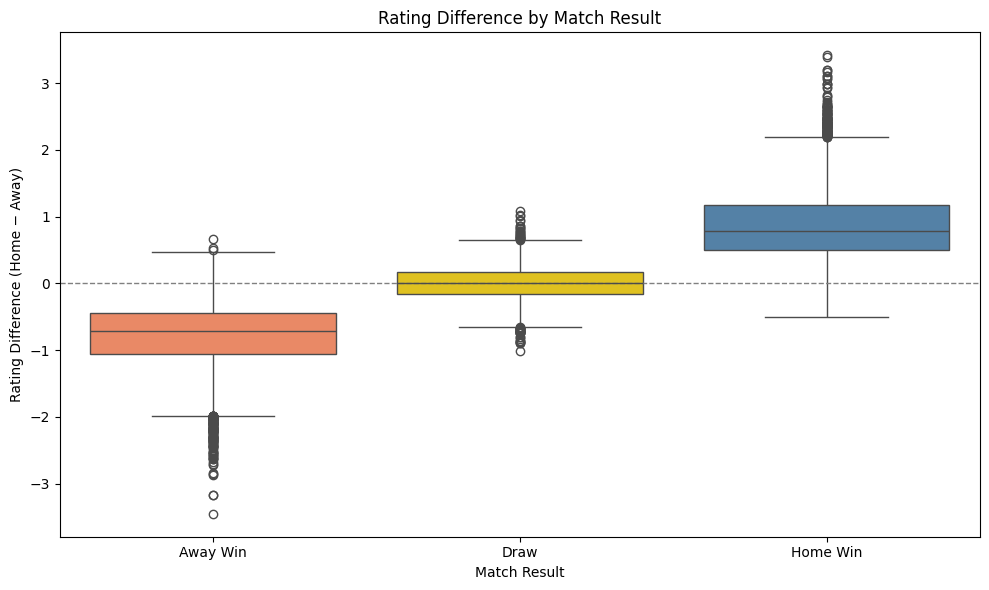

Average rating_difference by match_result:
               count   mean    std    min    25%    50%    75%    max
match_result                                                         
Away Win      4830.0 -0.788  0.498 -3.450 -1.058 -0.709 -0.444  0.665
Draw          3953.0  0.002  0.253 -1.020 -0.162  0.003  0.164  1.085
Home Win      7106.0  0.871  0.526 -0.501  0.498  0.786  1.177  3.416


In [45]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=df_clean, x='match_result', y='rating_difference', 
            order=['Away Win', 'Draw', 'Home Win'],
            palette={'Home Win': 'steelblue', 'Draw': 'gold', 'Away Win': 'coral'})
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Rating Difference by Match Result')
ax.set_xlabel('Match Result')
ax.set_ylabel('Rating Difference (Home \u2212 Away)')

plt.tight_layout()
plt.show()

print("Average rating_difference by match_result:")
print(df_clean.groupby('match_result')['rating_difference'].describe().round(3))

**Findings:**

- **Home Wins** are associated with a **positive** median `rating_difference` — the home team is typically rated higher.
- **Away Wins** show a **negative** median `rating_difference` — the away team is rated higher.
- **Draws** cluster around zero, confirming that evenly matched teams are more likely to draw.
- This pattern strongly supports the hypothesis that player ratings are predictive of match outcomes.

#### Formation vs Match Result

We analyze whether certain formations are linked to winning more often (home team perspective).

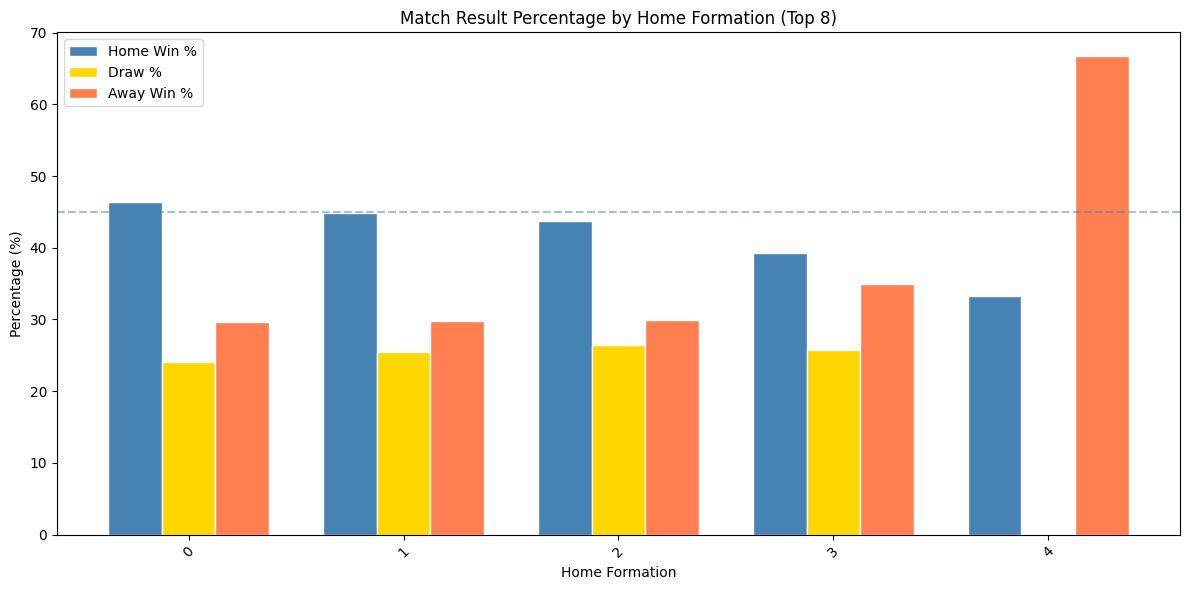

Match Result by Home Formation (Top 8):


match_result,Home_Win_Pct,Draw_Pct,Away_Win_Pct,Total
home_formation,,,,
0,46.4,24.0,29.6,8612
1,44.8,25.4,29.8,1713
2,43.7,26.4,29.9,3469
3,39.2,25.8,35.0,2092
4,33.3,0.0,66.7,3


In [46]:
# Cross-tab: home formation vs match result (top 8 formations)
top_formations = df_clean['home_formation'].value_counts().head(8).index
filtered = df_clean[df_clean['home_formation'].isin(top_formations)]

ct = pd.crosstab(filtered['home_formation'], filtered['match_result'])

# Calculate win % for each formation
ct['Total'] = ct.sum(axis=1)
ct['Home_Win_Pct'] = (ct['Home Win'] / ct['Total'] * 100).round(1)
ct['Away_Win_Pct'] = (ct['Away Win'] / ct['Total'] * 100).round(1)
ct['Draw_Pct'] = (ct['Draw'] / ct['Total'] * 100).round(1)

# Sort by Home Win %
ct_sorted = ct.sort_values('Home_Win_Pct', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(ct_sorted))
width = 0.25

ax.bar([i - width for i in x], ct_sorted['Home_Win_Pct'], width, label='Home Win %', color='steelblue', edgecolor='white')
ax.bar(x, ct_sorted['Draw_Pct'], width, label='Draw %', color='gold', edgecolor='white')
ax.bar([i + width for i in x], ct_sorted['Away_Win_Pct'], width, label='Away Win %', color='coral', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(ct_sorted.index.astype(str), rotation=45)
ax.set_title('Match Result Percentage by Home Formation (Top 8)')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Home Formation')
ax.legend()
ax.axhline(45, color='steelblue', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("Match Result by Home Formation (Top 8):")
ct_sorted[['Home_Win_Pct', 'Draw_Pct', 'Away_Win_Pct', 'Total']]

**Findings:**

- While there is some variation in win percentages across formations, the differences are relatively small.
- No single formation guarantees a dramatically higher win rate — the baseline home win rate (~45%) is broadly consistent across all common formations.
- This suggests that **formation alone is not a strong predictor of match outcome**; team quality (ratings) matters more.

### 3. SQL Analysis

To validate the findings from our EDA, we run several SQL queries on the same data loaded into SQLite.

In [47]:
# Set up SQLite connection and load data
import sqlite3
conn = sqlite3.connect("football_project.db")
df_clean.to_sql("cleaned_matches", conn, if_exists="replace", index=False)
print("SQLite table 'cleaned_matches' ready.")

SQLite table 'cleaned_matches' ready.


#### SQL: Average `rating_difference` by Formation

In [48]:
query_avg_rating_by_formation = """
SELECT
    home_formation,
    COUNT(*) AS match_count,
    ROUND(AVG(rating_difference), 3) AS avg_rating_diff
FROM cleaned_matches
WHERE home_formation IS NOT NULL
GROUP BY home_formation
HAVING match_count >= 50
ORDER BY avg_rating_diff DESC
LIMIT 15;
"""

pd.read_sql(query_avg_rating_by_formation, conn)

,home_formation,match_count,avg_rating_diff
0,0,8612,0.183
1,1,1713,0.174
2,2,3469,0.120
3,3,2092,0.048


#### SQL: Win Percentage by Formation

In [49]:
query_win_pct_by_formation = """
SELECT
    home_formation,
    COUNT(*) AS total_matches,
    SUM(CASE WHEN match_result = 'Home Win' THEN 1 ELSE 0 END) AS home_wins,
    ROUND(100.0 * SUM(CASE WHEN match_result = 'Home Win' THEN 1 ELSE 0 END) / COUNT(*), 1) AS home_win_pct,
    SUM(CASE WHEN match_result = 'Draw' THEN 1 ELSE 0 END) AS draws,
    ROUND(100.0 * SUM(CASE WHEN match_result = 'Draw' THEN 1 ELSE 0 END) / COUNT(*), 1) AS draw_pct,
    SUM(CASE WHEN match_result = 'Away Win' THEN 1 ELSE 0 END) AS away_wins,
    ROUND(100.0 * SUM(CASE WHEN match_result = 'Away Win' THEN 1 ELSE 0 END) / COUNT(*), 1) AS away_win_pct
FROM cleaned_matches
WHERE home_formation IS NOT NULL
GROUP BY home_formation
HAVING total_matches >= 100
ORDER BY home_win_pct DESC
LIMIT 15;
"""

pd.read_sql(query_win_pct_by_formation, conn)

,home_formation,total_matches,home_wins,home_win_pct,draws,draw_pct,away_wins,away_win_pct
0,0,8612,4000,46.4,2063,24.0,2549,29.6
1,1,1713,768,44.8,435,25.4,510,29.8
2,2,3469,1516,43.7,916,26.4,1037,29.9
3,3,2092,821,39.2,539,25.8,732,35.0


#### SQL: Average Ratings by League

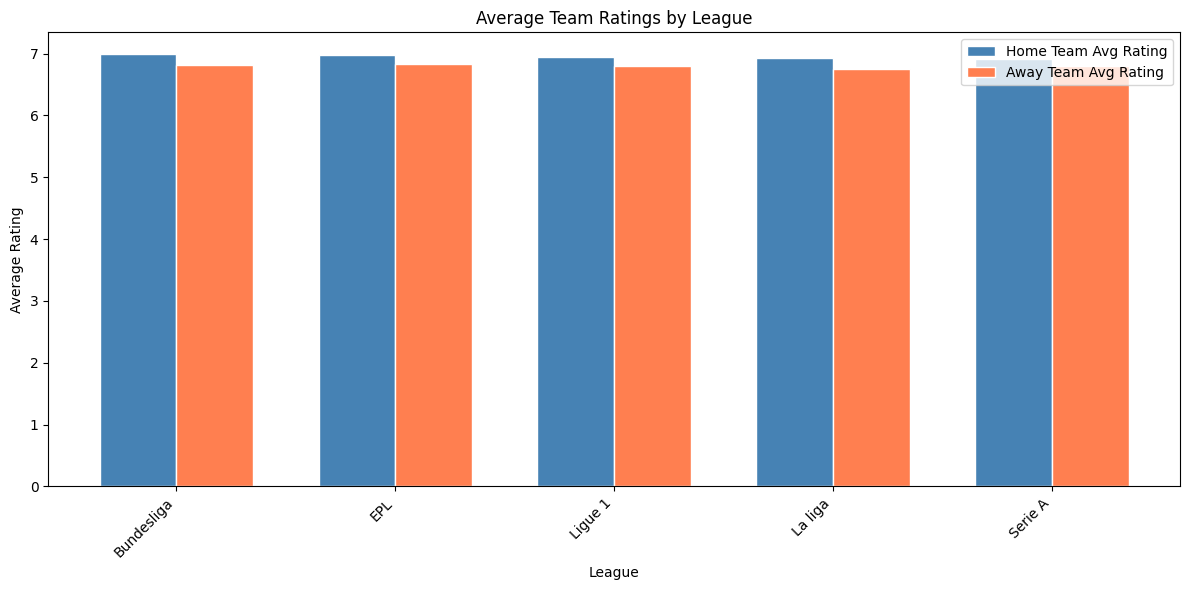

In [50]:
query_avg_ratings_by_league = """
SELECT
    league,
    COUNT(*) AS match_count,
    ROUND(AVG(average_home_team_rating), 2) AS avg_home_rating,
    ROUND(AVG(average_away_team_rating), 2) AS avg_away_rating,
    ROUND(AVG(rating_difference), 3) AS avg_rating_diff
FROM cleaned_matches
WHERE league IS NOT NULL
GROUP BY league
ORDER BY avg_home_rating DESC;
"""

pd.read_sql(query_avg_ratings_by_league, conn)

# Visualization: Average ratings by league
fig, ax = plt.subplots(figsize=(12, 6))

league_stats = df_clean.groupby('league').agg(
    avg_home_rating=('average_home_team_rating', 'mean'),
    avg_away_rating=('average_away_team_rating', 'mean')
).sort_values('avg_home_rating', ascending=False)

x = range(len(league_stats))
width = 0.35

ax.bar([i - width/2 for i in x], league_stats['avg_home_rating'], width, 
       label='Home Team Avg Rating', color='steelblue', edgecolor='white')
ax.bar([i + width/2 for i in x], league_stats['avg_away_rating'], width,
       label='Away Team Avg Rating', color='coral', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(league_stats.index, rotation=45, ha='right')
ax.set_title('Average Team Ratings by League')
ax.set_ylabel('Average Rating')
ax.set_xlabel('League')
ax.legend()

plt.tight_layout()
plt.show()

### 4. Extended Conclusions for Q4 + Q11 + Q12

#### Key Takeaways

1. **Player ratings strongly influence match outcomes.**
   - The correlation between `rating_difference` and `goal_difference` confirms that teams with higher-rated players tend to score more and concede fewer goals.
   - The boxplot of `rating_difference` by `match_result` shows a clear gradient: home wins when the home team has a rating advantage, away wins when the away team is stronger, and draws when ratings are balanced.

2. **Formations have a limited standalone impact.**
   - While certain formations show slightly higher win percentages, the differences are modest. No formation consistently outperforms the baseline home win rate (~45%) by a large margin.
   - The most popular formations (0: 4-2-3-1/4-3-3, 2: 4-4-2) are used by both strong and weak teams, so formation alone does not determine success.

3. **League-level differences exist but are small.**
   - The SQL analysis reveals that the top European leagues feature similar average team ratings, with only narrow spreads.
   - The average `rating_difference` across leagues is consistently near zero, meaning home and away teams are generally well-matched.

4. **Integration with earlier findings.**
   - Combined with Q1\u2013Q3, we see that **ratings complement xG and recent form** as predictors: teams with higher ratings generate more xG, win more points, and have better recent form \u2014 all reinforcing each other.
   - Player ratings provide a *structural* measure of team quality, while xG and recent form capture *situational* performance.

#### Final Verdict for Q4

> **Team player ratings are a strong predictor of match performance.** Higher-rated teams consistently score more goals, generate more expected goals, and win more matches. Team formation, by contrast, shows only a weak association with match outcomes and should be considered a secondary factor.

;lj;lj;